A

In [17]:
from pathlib import Path
import pandas as pd

# 找到 project root，不管 notebook 是從 notebooks/ 還是 project root 執行
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

DATA_FILE = ROOT / "202601_TUM Inventory Case Study Data.xlsx"

In [18]:
site_data = pd.read_excel(DATA_FILE, sheet_name="Site data", header=1)
products = pd.read_excel(DATA_FILE, sheet_name="Products", header=1)
demand = pd.read_excel(DATA_FILE, sheet_name="Demand", header=1)
inventory = pd.read_excel(DATA_FILE, sheet_name="Inventory", header=1)


#移除空欄
site_data = site_data.dropna(axis=1, how="all")
products = products.dropna(axis=1, how="all")
demand = demand.dropna(axis=1, how="all")
inventory = inventory.dropna(axis=1, how="all")

#轉格式日期
demand["Date"] = pd.to_datetime(
    demand["Date"].astype(str),
    format="%Y%m"
)

inventory["Date"] = pd.to_datetime(
    inventory["Date"].astype(str),
    format="%Y%m"
)

In [19]:
#合併demand和inventory
KEY = ["Product Code", "Site Code", "Date"]

analysis_data = demand.merge(
    inventory,
    on=KEY,
    how="inner",
    validate="one_to_one"
)

#加入product資訊
analysis_data = analysis_data.merge(
    products[
        [
            "Product Code",
            "Product group",
            "Product variant",
            "Sales Product Group",
            "Unit of Measure (UoM)",
            "Product value (€/UoM)"
        ]
    ],
    on="Product Code",
    how="left",
    validate="many_to_one"
)

#加入site資訊
analysis_data = analysis_data.merge(
    site_data[
        [
            "Site Code",
            "Site Name",
            "Site Type",
            "Site Country",
            "Site City"
        ]
    ],
    on="Site Code",
    how="left",
    validate="many_to_one"
)

In [20]:
# make sure
assert len(analysis_data) == len(demand) == len(inventory)

assert analysis_data[
    ["Product Code", "Site Code", "Date"]
].notna().all().all()

assert analysis_data[
    ["Product group", "Product value (€/UoM)", "Site City"]
].notna().all().all()

analysis_data.shape, analysis_data.head()

((1800, 15),
         Product Code                      Site Code       Date  \
 0  Jacket_J1_AllYear  WH_Germany_Munich_Maxvorstadt 2025-01-01   
 1  Jacket_J1_AllYear  WH_Germany_Munich_Maxvorstadt 2025-02-01   
 2  Jacket_J1_AllYear  WH_Germany_Munich_Maxvorstadt 2025-03-01   
 3  Jacket_J1_AllYear  WH_Germany_Munich_Maxvorstadt 2025-04-01   
 4  Jacket_J1_AllYear  WH_Germany_Munich_Maxvorstadt 2025-05-01   
 
    Demand monthly (UoM)  Inventory level (UoM)  Inventory value Product group  \
 0                     0                    542             8130        Jacket   
 1                     0                    542             8130        Jacket   
 2                     0                    542             8130        Jacket   
 3                     0                    542             8130        Jacket   
 4                     0                    542             8130        Jacket   
 
   Product variant Sales Product Group Unit of Measure (UoM)  \
 0      J1_AllYear       

In [21]:
import matplotlib.pyplot as plt

#規範各項 Analysis assumptions
ANALYSIS_YEAR = 2025
TARGET_MOS = 3.0
WACC = 0.10 #Weighted Average Cost of Capital

#Product Y has no demand since 12 months anymore but high stock
DEAD_STOCK_CUTOFF = pd.Timestamp("2025-01-01")
LATEST_DATE = analysis_data["Date"].max()

In [22]:
#畫production 與 warehousing sites在地圖上
import plotly.express as px

network = site_data.copy()

network["Site Type"] = network["Site Type"].replace({
    "WH": "Warehouse",
    "PS": "Production Site"
})

fig = px.scatter_geo(
    network,
    lon="Longitude",
    lat="Latitude",
    color="Site Type",
    hover_name="Site City",
    hover_data=["Site Name", "Site Country"],
    scope="europe",
    title="Adios Supply Network"
)

fig.update_traces(marker={"size": 10})
fig.update_geos(fitbounds="locations", visible=True)

fig.show()

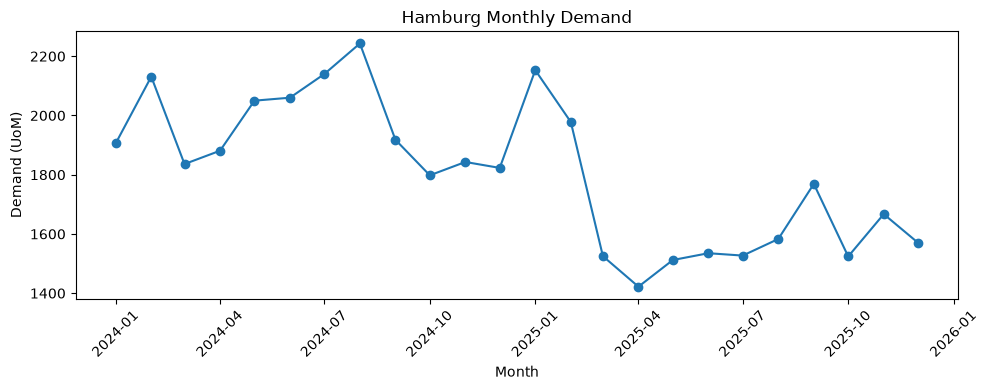

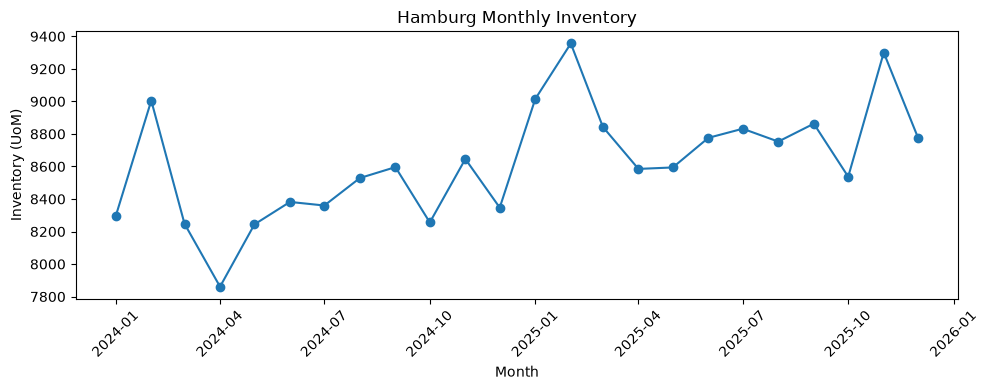

In [23]:
#總量算法Product × Site × Month
#算Hamburg總量
hamburg = analysis_data[
    analysis_data["Site City"] == "Hamburg"
].copy()

hamburg_monthly = (
    hamburg
    .groupby("Date", as_index=False)
    .agg(
        Demand=("Demand monthly (UoM)", "sum"),
        Inventory=("Inventory level (UoM)", "sum")
    )
)

hamburg_monthly

#畫Demand
plt.figure(figsize=(10, 4))

plt.plot(
    hamburg_monthly["Date"],
    hamburg_monthly["Demand"],
    marker="o"
)

plt.title("Hamburg Monthly Demand")
plt.xlabel("Month")
plt.ylabel("Demand (UoM)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

#畫 Inventory
plt.figure(figsize=(10, 4))

plt.plot(
    hamburg_monthly["Date"],
    hamburg_monthly["Inventory"],
    marker="o"
)

plt.title("Hamburg Monthly Inventory")
plt.xlabel("Month")
plt.ylabel("Inventory (UoM)")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


In [24]:
#查看D 和I的變化
hamburg_yearly = (
    hamburg_monthly
    .assign(Year=hamburg_monthly["Date"].dt.year)
    .groupby("Year", as_index=False)
    .agg(
        Annual_Demand=("Demand", "sum"),
        Average_Monthly_Inventory=("Inventory", "mean")
    )
)

hamburg_yearly

#Hamburg demand 約下降 16.4%，但：average inventory 約 上升 5.4%-->需求下降，但庫存沒有跟著下降，反而更高

#找出是哪個產品造成
hamburg_product_year = (
    hamburg
    .assign(Year=hamburg["Date"].dt.year)
    .groupby(
        ["Product Code", "Product variant", "Year"],
        as_index=False
    )
    .agg(
        Demand=("Demand monthly (UoM)", "sum"),
        Average_Inventory=("Inventory level (UoM)", "mean")
    )
)

#拆分2024和2025再會合成一張表
hamburg_2024 = (
    hamburg_product_year[
        hamburg_product_year["Year"] == 2024
    ]
    .drop(columns="Year")
    .rename(columns={
        "Demand": "Demand_2024",
        "Average_Inventory": "Average_Inventory_2024"
    })
)

hamburg_2025 = (
    hamburg_product_year[
        hamburg_product_year["Year"] == 2025
    ]
    .drop(columns="Year")
    .rename(columns={
        "Demand": "Demand_2025",
        "Average_Inventory": "Average_Inventory_2025"
    })
)

hamburg_change = hamburg_2024.merge(
    hamburg_2025,
    on=["Product Code", "Product variant"],
    how="inner",
    validate="one_to_one"
)

#計算變化量
hamburg_change["Demand_Change_pct"] = (
    (
        hamburg_change["Demand_2025"]
        / hamburg_change["Demand_2024"]
        - 1
    )
    * 100
)

hamburg_change["Inventory_Change_pct"] = (
    (
        hamburg_change["Average_Inventory_2025"]
        / hamburg_change["Average_Inventory_2024"]
        - 1
    )
    * 100
)

hamburg_change.sort_values(
    "Demand_Change_pct"
).head(10)

#Hint:Summer24,WorldCup24 ,24 may be the reason for low demand and high inventory


,Product Code,Product variant,Demand_2024,Average_Inventory_2024,Demand_2025,Average_Inventory_2025,Demand_Change_pct,Inventory_Change_pct
14,Shoes_S3_Summer24,S3_Summer24,1272,646.083333,0,719.000000,-100.000000,11.285954
5,Jacket_J3_WorldCup24,J3_WorldCup24,4677,653.250000,817,610.166667,-82.531537,-6.595229
8,Pants_P3_Beach,P3_Beach,1146,867.833333,1096,905.166667,-4.363002,4.301901
1,Hat_H2_SpecialLine,H2_SpecialLine,392,701.750000,395,741.750000,0.765306,5.700036
7,Pants_P2_Casual,P2_Casual,1346,671.083333,1390,728.750000,3.268945,8.593071
10,Shirt_TS2_LongSleeve,TS2_LongSleeve,1113,551.333333,1160,603.000000,4.222821,9.371221
2,Hat_H3_CapMen,H3_CapMen,992,511.500000,1036,555.166667,4.435484,8.536983
9,Shirt_TS1_Casual,TS1_Casual,2926,663.250000,3059,706.250000,4.545455,6.483227
6,Pants_P1_Performance,P1_Performance,1425,382.000000,1490,401.333333,4.561404,5.061082
0,Hat_H1_CapWomen,H1_CapWomen,658,329.916667,693,337.500000,5.319149,2.298560


In [25]:
# Use the latest complete year for current inventory performance
data_2025 = analysis_data[
    analysis_data["Date"].dt.year == ANALYSIS_YEAR
].copy()

# Build one row for each Site × Product
kpi = (
    data_2025
    .groupby(
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Product group",
            "Product variant",
            "Product value (€/UoM)"
        ],
        as_index=False
    )
    .agg(
        Annual_Demand=("Demand monthly (UoM)", "sum"),
        Average_Inventory=("Inventory level (UoM)", "mean"),
        Average_Inventory_Value_EUR=("Inventory value", "mean")
    )
)

# Core inventory KPIs
kpi["Average_Monthly_Demand"] = (
    kpi["Annual_Demand"] / 12
)

kpi["Inventory_Turns"] = (
    kpi["Annual_Demand"]
    / kpi["Average_Inventory"]
)

kpi["MOS"] = (
    kpi["Average_Inventory"]
    / kpi["Average_Monthly_Demand"]
)

# MOS is not meaningful when demand is zero
kpi.loc[
    kpi["Annual_Demand"] == 0,
    "MOS"
] = pd.NA

kpi.head()

,Site Code,Site City,Product Code,Product group,Product variant,Product value (€/UoM),Annual_Demand,Average_Inventory,Average_Inventory_Value_EUR,Average_Monthly_Demand,Inventory_Turns,MOS
0,WH_Germany_Berlin_Charlottenburg,Berlin,Hat_H1_CapWomen,Hat,H1_CapWomen,5,1311,456.333333,2281.666667,109.250000,2.872900,4.176964
1,WH_Germany_Berlin_Charlottenburg,Berlin,Hat_H2_SpecialLine,Hat,H2_SpecialLine,4,1104,566.750000,2267.000000,92.000000,1.947949,6.160326
2,WH_Germany_Berlin_Charlottenburg,Berlin,Hat_H3_CapMen,Hat,H3_CapMen,3,3156,594.000000,1782.000000,263.000000,5.313131,2.258555
3,WH_Germany_Berlin_Charlottenburg,Berlin,Jacket_J1_AllYear,Jacket,J1_AllYear,15,1556,410.583333,6158.750000,129.666667,3.789730,3.166452
4,WH_Germany_Berlin_Charlottenburg,Berlin,Jacket_J2_Winter,Jacket,J2_Winter,12,1296,641.166667,7694.000000,108.000000,2.021315,5.936728


In [26]:
#Analyze dead stock

last_sold = (
    analysis_data[
        analysis_data["Demand monthly (UoM)"] > 0
    ]
    .groupby(
        ["Site Code", "Product Code"],
        as_index=False
    )
    .agg(
        Last_Sold=("Date", "max")
    )
)

#find last sold and current inventory
last_sold = (
    analysis_data[
        analysis_data["Demand monthly (UoM)"] > 0
    ]
    .groupby(
        ["Site Code", "Product Code"],
        as_index=False
    )
    .agg(
        Last_Sold=("Date", "max")
    )
)

current_inventory = (
    analysis_data[
        analysis_data["Date"] == LATEST_DATE
    ][
        [
            "Site Code",
            "Product Code",
            "Inventory level (UoM)",
            "Inventory value"
        ]
    ]
    .rename(
        columns={
            "Inventory level (UoM)": "Current_Inventory",
            "Inventory value": "Current_Inventory_Value_EUR"
        }
    )
)


kpi = kpi.merge(
    last_sold,
    on=["Site Code", "Product Code"],
    how="left",
    validate="one_to_one"
)

kpi = kpi.merge(
    current_inventory,
    on=["Site Code", "Product Code"],
    how="left",
    validate="one_to_one"
)

#dead stock
kpi["Dead_Stock"] = (
    (kpi["Annual_Demand"] == 0)
    & (kpi["Current_Inventory"] > 0)
)

dead_stock = (
    kpi[
        kpi["Dead_Stock"]
    ]
    .sort_values(
        "Current_Inventory_Value_EUR",
        ascending=False
    )
    .copy()
)

dead_stock[
    [
        "Site City",
        "Product Code",
        "Last_Sold",
        "Current_Inventory",
        "Current_Inventory_Value_EUR"
    ]
]



,Site City,Product Code,Last_Sold,Current_Inventory,Current_Inventory_Value_EUR
44,Hamburg,Shoes_S3_Summer24,2024-08-01,719,21570
63,Munich,Jacket_J1_AllYear,2024-12-01,542,8130
19,Frankfurt,Jacket_J2_Winter,2024-06-01,479,5748
6,Berlin,Pants_P1_Performance,2024-10-01,458,5496
54,Kassel,Shirt_TS1_Casual,2024-12-01,532,5320
68,Munich,Pants_P3_Beach,2024-12-01,507,4056
56,Kassel,Shirt_TS3_Luxury,2024-12-01,601,3606
61,Munich,Hat_H2_SpecialLine,2024-06-01,424,1696


In [27]:
#Excess Inventory and Reduction Potential
#TARGET_MOS = 3.0,WACC = 0.10(cell 5 assume)

# Inventory needed under the target MOS assumption
kpi["Target_Inventory"] = (
    kpi["Average_Monthly_Demand"]
    * TARGET_MOS
)

# Inventory above the target level
kpi["Excess_Inventory"] = (
    kpi["Average_Inventory"]
    - kpi["Target_Inventory"]
).clip(lower=0)

# Working-capital reduction potential
kpi["Reduction_Potential_EUR"] = (
    kpi["Excess_Inventory"]
    * kpi["Product value (€/UoM)"]
)

# Financing cost based on WACC assumption
kpi["Annual_Capital_Cost_EUR"] = (
    kpi["Average_Inventory_Value_EUR"]
    * WACC
)

kpi["Annual_Capital_Cost_Saving_EUR"] = (
    kpi["Reduction_Potential_EUR"]
    * WACC
)


kpi["High_MOS"] = (
    kpi["MOS"].fillna(0)
    > TARGET_MOS
)

kpi["Problematic"] = (
    kpi["Dead_Stock"]
    | kpi["High_MOS"]
)

problem_items = (
    kpi[
        kpi["Problematic"]
    ]
    .sort_values(
        "Reduction_Potential_EUR",
        ascending=False
    )
    .copy()
)

problem_items[
    [
        "Site City",
        "Product Code",
        "Annual_Demand",
        "Average_Inventory",
        "Inventory_Turns",
        "MOS",
        "Dead_Stock",
        "Reduction_Potential_EUR"
    ]
].head(15)


,Site City,Product Code,Annual_Demand,Average_Inventory,Inventory_Turns,MOS,Dead_Stock,Reduction_Potential_EUR
44,Hamburg,Shoes_S3_Summer24,0,719.000000,0.000000,NaN,True,21570.000000
73,Munich,Shoes_S2_SneakerOutdoor,1771,771.166667,2.296520,5.225296,False,11494.583333
14,Berlin,Shoes_S3_Summer24,1496,717.833333,2.084049,5.758021,False,10315.000000
27,Frankfurt,Shoes_S1_SneakerIndoor,2384,804.000000,2.965174,4.046980,False,8320.000000
63,Munich,Jacket_J1_AllYear,0,542.000000,0.000000,NaN,True,8130.000000
19,Frankfurt,Jacket_J2_Winter,0,479.000000,0.000000,NaN,True,5748.000000
6,Berlin,Pants_P1_Performance,0,458.000000,0.000000,NaN,True,5496.000000
66,Munich,Pants_P1_Performance,1423,813.333333,1.749590,6.858749,False,5491.000000
18,Frankfurt,Jacket_J1_AllYear,1731,797.250000,2.171214,5.526863,False,5467.500000
54,Kassel,Shirt_TS1_Casual,0,532.000000,0.000000,NaN,True,5320.000000


In [28]:
#management level result

#Network 有多少 inventory？
#dead stock 有多大？
#哪個 site reduction potential 最大？

kpi["Dead_Stock_Value_EUR"] = 0.0

kpi.loc[
    kpi["Dead_Stock"],
    "Dead_Stock_Value_EUR"
] = kpi.loc[
    kpi["Dead_Stock"],
    "Current_Inventory_Value_EUR"
]

site_summary = (
    kpi
    .groupby(
        "Site City",
        as_index=False
    )
    .agg(
        Average_Inventory_Value_EUR=(
            "Average_Inventory_Value_EUR",
            "sum"
        ),
        Dead_Stock_Value_EUR=(
            "Dead_Stock_Value_EUR",
            "sum"
        ),
        Reduction_Potential_EUR=(
            "Reduction_Potential_EUR",
            "sum"
        ),
        Annual_Capital_Cost_Saving_EUR=(
            "Annual_Capital_Cost_Saving_EUR",
            "sum"
        ),
        Problematic_Items=(
            "Problematic",
            "sum"
        )
    )
    .sort_values(
        "Reduction_Potential_EUR",
        ascending=False
    )
)

current_inventory_value = (
    kpi["Current_Inventory_Value_EUR"].sum()
)

average_inventory_value = (
    kpi["Average_Inventory_Value_EUR"].sum()
)

dead_stock_value = (
    kpi["Dead_Stock_Value_EUR"].sum()
)

dead_stock_share = (
    dead_stock_value
    / current_inventory_value
)

reduction_potential = (
    kpi["Reduction_Potential_EUR"].sum()
)

reduction_potential_share = (
    reduction_potential
    / average_inventory_value
)

annual_capital_cost_saving = (
    kpi["Annual_Capital_Cost_Saving_EUR"].sum()
)




In [29]:
print(
    f"Current inventory value: "
    f"€{current_inventory_value:,.0f}"
)

print(
    f"Dead stock value: "
    f"€{dead_stock_value:,.0f}"
)

print(
    f"Dead stock share: "
    f"{dead_stock_share:.1%}"
)

print(
    f"Inventory reduction potential: "
    f"€{reduction_potential:,.0f}"
)

print(
    f"Reduction potential share: "
    f"{reduction_potential_share:.1%}"
)

print(
    f"Annual capital cost saving: "
    f"€{annual_capital_cost_saving:,.0f}"
)

print(
    f"€194.7k estimated working-capital release potential under a 3-month target MOS assumption"
)

print("\nSite ranking by inventory reduction potential:")

for rank, (_, row) in enumerate(site_summary.iterrows(), start=1):
    print(
        f"{rank}. {row['Site City']}: "
        f"€{row['Reduction_Potential_EUR']:,.0f}"
    )

Current inventory value: €630,874
Dead stock value: €55,622
Dead stock share: 8.8%
Inventory reduction potential: €194,670
Reduction potential share: 31.5%
Annual capital cost saving: €19,467
€194.7k estimated working-capital release potential under a 3-month target MOS assumption

Site ranking by inventory reduction potential:
1. Hamburg: €47,960
2. Frankfurt: €43,320
3. Munich: €42,209
4. Berlin: €36,189
5. Kassel: €24,992


B

Network demand change: -8.2%
Network average inventory value change: +5.1%



,Site City,Demand_Change_pct,Inventory_Value_Change_pct
2,Hamburg,-16.4,5.8
3,Kassel,-13.1,4.5
4,Munich,-9.2,4.1
0,Berlin,-5.3,5.4
1,Frankfurt,3.3,5.5


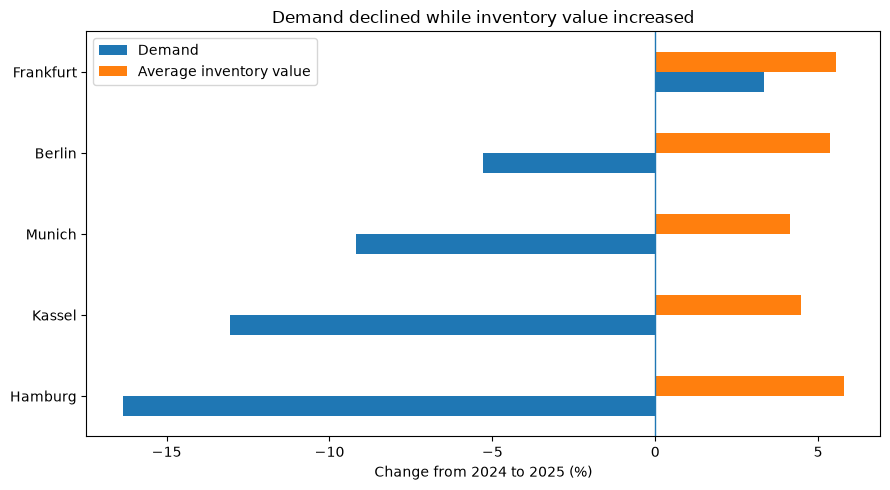

In [30]:
# ============================================================
# B1 — Demand vs. inventory change
# ============================================================

OUTPUT_DIR = ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)


# ------------------------------------------------------------
# 1. Annual demand by site
# ------------------------------------------------------------

site_demand_yearly = (
    analysis_data
    .assign(
        Year=analysis_data["Date"].dt.year
    )
    .groupby(
        ["Site City", "Year"],
        as_index=False
    )
    .agg(
        Annual_Demand=(
            "Demand monthly (UoM)",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 2. Average inventory value by site and year
#
# Important:
# First calculate TOTAL inventory value for each Site × Month.
# Then average the monthly totals within each year.
# ------------------------------------------------------------

site_inventory_monthly = (
    analysis_data
    .assign(
        Year=analysis_data["Date"].dt.year
    )
    .groupby(
        ["Site City", "Year", "Date"],
        as_index=False
    )
    .agg(
        Monthly_Inventory_Value_EUR=(
            "Inventory value",
            "sum"
        )
    )
)

site_inventory_yearly = (
    site_inventory_monthly
    .groupby(
        ["Site City", "Year"],
        as_index=False
    )
    .agg(
        Average_Inventory_Value_EUR=(
            "Monthly_Inventory_Value_EUR",
            "mean"
        )
    )
)


# ------------------------------------------------------------
# 3. Combine demand and inventory
# ------------------------------------------------------------

site_year = site_demand_yearly.merge(
    site_inventory_yearly,
    on=["Site City", "Year"],
    how="inner",
    validate="one_to_one"
)


# Convert 2024 / 2025 into columns
site_change = site_year.pivot(
    index="Site City",
    columns="Year",
    values=[
        "Annual_Demand",
        "Average_Inventory_Value_EUR"
    ]
)

site_change.columns = [
    f"{metric}_{year}"
    for metric, year in site_change.columns
]

site_change = site_change.reset_index()


# ------------------------------------------------------------
# 4. Calculate 2024 → 2025 percentage changes
# ------------------------------------------------------------

site_change["Demand_Change_pct"] = (
    (
        site_change["Annual_Demand_2025"]
        / site_change["Annual_Demand_2024"]
        - 1
    )
    * 100
)

site_change["Inventory_Value_Change_pct"] = (
    (
        site_change[
            "Average_Inventory_Value_EUR_2025"
        ]
        / site_change[
            "Average_Inventory_Value_EUR_2024"
        ]
        - 1
    )
    * 100
)

site_change = site_change.sort_values(
    "Demand_Change_pct"
)


# ------------------------------------------------------------
# 5. Network-level comparison
# ------------------------------------------------------------

network_demand_yearly = (
    analysis_data
    .assign(
        Year=analysis_data["Date"].dt.year
    )
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        Annual_Demand=(
            "Demand monthly (UoM)",
            "sum"
        )
    )
)


network_inventory_monthly = (
    analysis_data
    .assign(
        Year=analysis_data["Date"].dt.year
    )
    .groupby(
        ["Year", "Date"],
        as_index=False
    )
    .agg(
        Monthly_Inventory_Value_EUR=(
            "Inventory value",
            "sum"
        )
    )
)


network_inventory_yearly = (
    network_inventory_monthly
    .groupby(
        "Year",
        as_index=False
    )
    .agg(
        Average_Inventory_Value_EUR=(
            "Monthly_Inventory_Value_EUR",
            "mean"
        )
    )
)


network_year = network_demand_yearly.merge(
    network_inventory_yearly,
    on="Year",
    how="inner",
    validate="one_to_one"
)


network_2024 = network_year.loc[
    network_year["Year"] == 2024
].iloc[0]

network_2025 = network_year.loc[
    network_year["Year"] == 2025
].iloc[0]


network_demand_change_pct = (
    (
        network_2025["Annual_Demand"]
        / network_2024["Annual_Demand"]
        - 1
    )
    * 100
)

network_inventory_change_pct = (
    (
        network_2025["Average_Inventory_Value_EUR"]
        / network_2024["Average_Inventory_Value_EUR"]
        - 1
    )
    * 100
)


# ------------------------------------------------------------
# 6. Print results
# ------------------------------------------------------------

print(
    f"Network demand change: "
    f"{network_demand_change_pct:+.1f}%"
)

print(
    f"Network average inventory value change: "
    f"{network_inventory_change_pct:+.1f}%"
)

print()

display(
    site_change[
        [
            "Site City",
            "Demand_Change_pct",
            "Inventory_Value_Change_pct"
        ]
    ].round(1)
)


# ------------------------------------------------------------
# 7. Visualization
# ------------------------------------------------------------

plot_data = (
    site_change
    .set_index("Site City")
    [
        [
            "Demand_Change_pct",
            "Inventory_Value_Change_pct"
        ]
    ]
    .rename(
        columns={
            "Demand_Change_pct":
                "Demand",
            "Inventory_Value_Change_pct":
                "Average inventory value"
        }
    )
)


ax = plot_data.plot(
    kind="barh",
    figsize=(9, 5)
)

ax.axvline(
    0,
    linewidth=1
)

ax.set_title(
    "Demand declined while inventory value increased"
)

ax.set_xlabel(
    "Change from 2024 to 2025 (%)"
)

ax.set_ylabel("")

fig = ax.get_figure()

fig.tight_layout()

fig.savefig(
    OUTPUT_DIR
    / "B01_demand_vs_inventory_by_site.png",
    dpi=200,
    bbox_inches="tight"
)

plt.show()


site_change.to_csv(
    OUTPUT_DIR / "B01_site_change.csv",
    index=False
)

The pattern suggests that replenishment or inventory parameters may have reacted too slowly to declining demand.

In [31]:
# ============================================================
# B2 — Local dead stock and cross-site demand mismatch
# ============================================================


# ------------------------------------------------------------
# 1. Calculate 2025 network demand for each product
# ------------------------------------------------------------

network_product_demand_2025 = (
    data_2025
    .groupby(
        "Product Code",
        as_index=False
    )
    .agg(
        Network_Demand_2025=(
            "Demand monthly (UoM)",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 2. Add network demand to A's existing dead_stock table
# ------------------------------------------------------------

dead_stock_reason = (
    dead_stock[
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Product variant",
            "Annual_Demand",
            "Current_Inventory",
            "Current_Inventory_Value_EUR",
            "Last_Sold"
        ]
    ]
    .merge(
        network_product_demand_2025,
        on="Product Code",
        how="left",
        validate="many_to_one"
    )
)


# ------------------------------------------------------------
# 3. Demand at all OTHER warehouses
# ------------------------------------------------------------

dead_stock_reason[
    "Other_Sites_Demand_2025"
] = (
    dead_stock_reason[
        "Network_Demand_2025"
    ]
    - dead_stock_reason[
        "Annual_Demand"
    ]
)


dead_stock_reason[
    "Demand_Elsewhere"
] = (
    dead_stock_reason[
        "Other_Sites_Demand_2025"
    ] > 0
)


dead_stock_reason = (
    dead_stock_reason
    .sort_values(
        "Current_Inventory_Value_EUR",
        ascending=False
    )
)


# ------------------------------------------------------------
# 4. Results
# ------------------------------------------------------------

print(
    f"Local dead-stock positions: "
    f"{len(dead_stock_reason)}"
)

print(
    f"Dead-stock value: "
    f"€{dead_stock_reason['Current_Inventory_Value_EUR'].sum():,.0f}"
)

print(
    "Positions where the same SKU still has "
    "demand elsewhere: "
    f"{dead_stock_reason['Demand_Elsewhere'].sum()}"
    f"/{len(dead_stock_reason)}"
)


display(
    dead_stock_reason[
        [
            "Site City",
            "Product Code",
            "Last_Sold",
            "Current_Inventory_Value_EUR",
            "Other_Sites_Demand_2025",
            "Demand_Elsewhere"
        ]
    ]
)


dead_stock_reason.to_csv(
    OUTPUT_DIR
    / "B02_dead_stock_rebalancing.csv",
    index=False
)

Local dead-stock positions: 8
Dead-stock value: €55,622
Positions where the same SKU still has demand elsewhere: 8/8


,Site City,Product Code,Last_Sold,Current_Inventory_Value_EUR,Other_Sites_Demand_2025,Demand_Elsewhere
0,Hamburg,Shoes_S3_Summer24,2024-08-01,21570,12107,True
1,Munich,Jacket_J1_AllYear,2024-12-01,8130,6066,True
2,Frankfurt,Jacket_J2_Winter,2024-06-01,5748,7634,True
3,Berlin,Pants_P1_Performance,2024-10-01,5496,6082,True
4,Kassel,Shirt_TS1_Casual,2024-12-01,5320,8109,True
5,Munich,Pants_P3_Beach,2024-12-01,4056,6608,True
6,Kassel,Shirt_TS3_Luxury,2024-12-01,3606,5815,True
7,Munich,Hat_H2_SpecialLine,2024-06-01,1696,3380,True


In [32]:
# ============================================================
# B3 — Seasonality and intermittent demand
# ============================================================


# ------------------------------------------------------------
# 1. 2025 demand pattern for each Site × Product
# ------------------------------------------------------------

demand_pattern = (
    data_2025
    .groupby(
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Product variant"
        ],
        as_index=False
    )
    .agg(
        Annual_Demand=(
            "Demand monthly (UoM)",
            "sum"
        ),
        Average_Monthly_Demand=(
            "Demand monthly (UoM)",
            "mean"
        ),
        Demand_Std=(
            "Demand monthly (UoM)",
            "std"
        ),
        Zero_Demand_Months=(
            "Demand monthly (UoM)",
            lambda s: int(
                (s == 0).sum()
            )
        )
    )
)


# ------------------------------------------------------------
# 2. Coefficient of Variation
#
# CV = standard deviation / mean
#
# Higher CV means demand is more volatile
# relative to its average level.
# ------------------------------------------------------------

demand_pattern["Demand_CV"] = (
    demand_pattern["Demand_Std"]
    / demand_pattern["Average_Monthly_Demand"]
)

demand_pattern.loc[
    demand_pattern["Average_Monthly_Demand"] == 0,
    "Demand_CV"
] = pd.NA


# ------------------------------------------------------------
# 3. Keep active products that still have zero-demand months
# ------------------------------------------------------------

intermittent_demand = (
    demand_pattern[
        (demand_pattern["Annual_Demand"] > 0)
        & (
            demand_pattern[
                "Zero_Demand_Months"
            ] > 0
        )
    ]
    .sort_values(
        [
            "Zero_Demand_Months",
            "Demand_CV"
        ],
        ascending=False
    )
    .copy()
)


# ------------------------------------------------------------
# 4. Results
# ------------------------------------------------------------

print(
    "Active Site × Product positions "
    "with zero-demand months: "
    f"{len(intermittent_demand)}"
)


display(
    intermittent_demand[
        [
            "Site City",
            "Product Code",
            "Annual_Demand",
            "Zero_Demand_Months",
            "Demand_CV"
        ]
    ].round(
        {
            "Demand_CV": 2
        }
    )
)


intermittent_demand.to_csv(
    OUTPUT_DIR
    / "B03_intermittent_demand.csv",
    index=False
)

Active Site × Product positions with zero-demand months: 5


,Site City,Product Code,Annual_Demand,Zero_Demand_Months,Demand_CV
31,Hamburg,Hat_H2_SpecialLine,395,10,2.36
35,Hamburg,Jacket_J3_WorldCup24,817,10,2.35
47,Kassel,Hat_H3_CapMen,448,10,2.34
38,Hamburg,Pants_P3_Beach,1096,7,1.25
34,Hamburg,Jacket_J2_Winter,1539,5,0.92


In [33]:
# ============================================================
# B4-1 — Prepare summary numbers for the root-cause matrix
# ============================================================

n_dead_positions = len(dead_stock_reason)

n_dead_elsewhere = int(
    dead_stock_reason["Demand_Elsewhere"].sum()
)

n_intermittent_positions = len(
    intermittent_demand
)

n_products = products[
    "Product Code"
].nunique()

n_warehouses = int(
    (
        site_data["Site Type"] == "WH"
    ).sum()
)

# ============================================================
# B4-2A — Data-backed root causes
# ============================================================

root_causes_data_backed = pd.DataFrame(
    [
        {
            "Reason":
                "Demand decline / planning lag",

            "Scope":
                "General",

            "Mechanism":
                (
                    "Demand falls faster than replenishment "
                    "targets or order plans are reduced, so "
                    "inventory does not decline with sales."
                ),

            "Case_Evidence":
                (
                    f"Network demand changed "
                    f"{network_demand_change_pct:+.1f}% "
                    f"vs. 2024, while average inventory "
                    f"value changed "
                    f"{network_inventory_change_pct:+.1f}%."
                ),

            "Resulting_Cost":
                (
                    "Working capital; warehousing; handling; "
                    "markdown / obsolescence"
                ),

            "Evidence_Level":
                (
                    "Strong data signal; forecast and order "
                    "data would be required to prove the "
                    "exact planning cause."
                ),
        },

        {
            "Reason":
                "Local allocation / rebalancing mismatch",

            "Scope":
                "General / multi-site retail",

            "Mechanism":
                (
                    "Stock remains at a location after local "
                    "demand disappears even though the same "
                    "SKU is still demanded elsewhere."
                ),

            "Case_Evidence":
                (
                    f"{n_dead_positions} zero-demand "
                    f"Site × Product positions hold "
                    f"€{dead_stock_value:,.0f}; "
                    f"{n_dead_elsewhere}/"
                    f"{n_dead_positions} of these SKUs "
                    f"still have demand at other sites."
                ),

            "Resulting_Cost":
                (
                    "Working capital; local warehousing; "
                    "transfer / markdown / scrap"
                ),

            "Evidence_Level":
                "Directly supported by case data.",
        },

        {
            "Reason":
                "Seasonality / short selling windows",

            "Scope":
                "Fashion / retail",

            "Mechanism":
                (
                    "Demand is concentrated in limited "
                    "seasons or events; inventory remaining "
                    "after the selling window becomes "
                    "slow-moving."
                ),

            "Case_Evidence":
                (
                    f"{n_intermittent_positions} active "
                    f"Site × Product positions have "
                    f"zero-demand months in 2025."
                ),

            "Resulting_Cost":
                (
                    "Working capital; warehousing; markdown; "
                    "obsolescence / scrap"
                ),

            "Evidence_Level":
                (
                    "Demand pattern directly observed; "
                    "inventory-policy parameters are not "
                    "available."
                ),
        },
    ]
)

display(root_causes_data_backed)

,Reason,Scope,Mechanism,Case_Evidence,Resulting_Cost,Evidence_Level
0,Demand decline / planning lag,General,Demand falls faster than replenishment targets...,"Network demand changed -8.2% vs. 2024, while a...",Working capital; warehousing; handling; markdo...,Strong data signal; forecast and order data wo...
1,Local allocation / rebalancing mismatch,General / multi-site retail,Stock remains at a location after local demand...,8 zero-demand Site × Product positions hold €5...,Working capital; local warehousing; transfer /...,Directly supported by case data.
2,Seasonality / short selling windows,Fashion / retail,Demand is concentrated in limited seasons or e...,5 active Site × Product positions have zero-de...,Working capital; warehousing; markdown; obsole...,Demand pattern directly observed; inventory-po...


In [34]:
# ============================================================
# B4-2B — Structural and hypothesis-based root causes
# ============================================================

n_stocking_positions = (
    n_products
    * n_warehouses
)

root_causes_hypotheses = pd.DataFrame(
    [
        {
            "Reason":
                "Product-location complexity",

            "Scope":
                "General / retail",

            "Mechanism":
                (
                    "More SKU-location combinations increase "
                    "planning and allocation complexity and "
                    "may create duplicated local buffers."
                ),

            "Case_Evidence":
                (
                    f"{n_products} products across "
                    f"{n_warehouses} German warehouses "
                    f"create {n_stocking_positions} "
                    f"Site × Product stocking positions."
                ),

            "Resulting_Cost":
                (
                    "Working capital; warehousing; handling; "
                    "planning effort"
                ),

            "Evidence_Level":
                (
                    "Structural observation; duplicated "
                    "safety stock cannot be proven."
                ),
        },

        {
            "Reason":
                "Long / volatile lead times",

            "Scope":
                "Supply side",

            "Mechanism":
                (
                    "Longer or less reliable replenishment "
                    "requires more inventory protection to "
                    "maintain service levels."
                ),

            "Case_Evidence":
                (
                    "The case background highlights supply "
                    "chain uncertainty and extended lead "
                    "times, but actual lead-time history is "
                    "not available in the analyzed data."
                ),

            "Resulting_Cost":
                (
                    "Working capital; warehousing; "
                    "possible premium freight"
                ),

            "Evidence_Level":
                (
                    "Case-supported hypothesis; "
                    "not quantitatively proven."
                ),
        },

        {
            "Reason":
                "Conservative inventory policy / order batches",

            "Scope":
                "Inventory policy",

            "Mechanism":
                (
                    "High safety-stock targets, stale "
                    "parameters, minimum order quantities or "
                    "large order batches can create excess "
                    "buffer or cycle stock."
                ),

            "Case_Evidence":
                (
                    "The analyzed A dataset does not include "
                    "actual safety-stock targets, service "
                    "levels, MOQ or order history."
                ),

            "Resulting_Cost":
                (
                    "Working capital; warehousing; "
                    "obsolescence risk"
                ),

            "Evidence_Level":
                (
                    "General hypothesis; additional "
                    "operational data required."
                ),
        },
    ]
)

display(root_causes_hypotheses)

,Reason,Scope,Mechanism,Case_Evidence,Resulting_Cost,Evidence_Level
0,Product-location complexity,General / retail,More SKU-location combinations increase planni...,15 products across 5 German warehouses create ...,Working capital; warehousing; handling; planni...,Structural observation; duplicated safety stoc...
1,Long / volatile lead times,Supply side,Longer or less reliable replenishment requires...,The case background highlights supply chain un...,Working capital; warehousing; possible premium...,Case-supported hypothesis; not quantitatively ...
2,Conservative inventory policy / order batches,Inventory policy,"High safety-stock targets, stale parameters, m...",The analyzed A dataset does not include actual...,Working capital; warehousing; obsolescence risk,General hypothesis; additional operational dat...


In [37]:
# ============================================================
# B5-1 — Inventory-related cost classification
# ============================================================

#differentiate between fixed and variable cost 定義不同分類的Cost
cost_classification = pd.DataFrame(
    [
        {
            "Cost":
                "Working capital / financing cost",

            "Behavior":
                "Variable",

            "Reason":
                (
                    "More inventory ties up more capital."
                ),

            "Inventory_Reduction_Effect":
                (
                    "Inventory reduction directly reduces "
                    "capital tied up and therefore financing "
                    "cost."
                ),
        },

        {
            "Cost":
                "Warehouse rent / permanent capacity",

            "Behavior":
                "Fixed / step-fixed",

            "Reason":
                (
                    "Warehouse buildings or contracted "
                    "capacity remain even after moderate "
                    "inventory reduction."
                ),

            "Inventory_Reduction_Effect":
                (
                    "Savings occur only when enough space "
                    "can actually be released."
                ),
        },

        {
            "Cost":
                "External / overflow storage",

            "Behavior":
                "Variable / step-variable",

            "Reason":
                (
                    "External storage fees often depend on "
                    "used pallets, space or storage duration."
                ),

            "Inventory_Reduction_Effect":
                (
                    "Costs can decline relatively quickly "
                    "when inventory is removed."
                ),
        },

        {
            "Cost":
                "Handling",

            "Behavior":
                "Mixed",

            "Reason":
                (
                    "Receiving, moving and counting stock "
                    "creates activity-related workload."
                ),

            "Inventory_Reduction_Effect":
                (
                    "Variable handling activity may decrease, "
                    "while permanent labor remains fixed."
                ),
        },

        {
            "Cost":
                "Markdown / obsolescence / scrap",

            "Behavior":
                "Variable / one-off",

            "Reason":
                (
                    "Unsold fashion products lose economic "
                    "value as their selling window closes."
                ),

            "Inventory_Reduction_Effect":
                (
                    "Better planning avoids future markdowns "
                    "and write-offs; disposal may itself "
                    "create one-off cost."
                ),
        },

        {
            "Cost":
                "Inventory rebalancing transport",

            "Behavior":
                "Variable / implementation cost",

            "Reason":
                (
                    "Moving stock between sites generates "
                    "transport and handling cost."
                ),

            "Inventory_Reduction_Effect":
                (
                    "The implementation cost must be compared "
                    "with the value recovered from stranded "
                    "inventory."
                ),
        },
    ]
)

display(cost_classification)

# ============================================================
# B5-2 — Financing-cost implication
# ============================================================

current_capital_cost = (
    average_inventory_value
    * WACC
)

dead_stock_capital_cost = (
    dead_stock_value
    * WACC
)

print(
    f"Estimated annual financing cost of "
    f"average inventory: "
    f"€{current_capital_cost:,.0f}"
)

print(
    f"Estimated annual financing cost tied "
    f"to dead stock: "
    f"€{dead_stock_capital_cost:,.0f}"
)

cost_classification.to_csv(
    OUTPUT_DIR / "B05_cost_classification.csv",
    index=False
)

,Cost,Behavior,Reason,Inventory_Reduction_Effect
0,Working capital / financing cost,Variable,More inventory ties up more capital.,Inventory reduction directly reduces capital t...
1,Warehouse rent / permanent capacity,Fixed / step-fixed,Warehouse buildings or contracted capacity rem...,Savings occur only when enough space can actua...
2,External / overflow storage,Variable / step-variable,External storage fees often depend on used pal...,Costs can decline relatively quickly when inve...
3,Handling,Mixed,"Receiving, moving and counting stock creates a...","Variable handling activity may decrease, while..."
4,Markdown / obsolescence / scrap,Variable / one-off,Unsold fashion products lose economic value as...,Better planning avoids future markdowns and wr...
5,Inventory rebalancing transport,Variable / implementation cost,Moving stock between sites generates transport...,The implementation cost must be compared with ...


Estimated annual financing cost of average inventory: €61,707
Estimated annual financing cost tied to dead stock: €5,562


In [40]:
# ============================================================
# B6-1 — Management-level root-cause summary
# ============================================================

b_summary = pd.DataFrame(
    [
        {
            "Priority": 1,

            "Finding":
                "Inventory did not adjust to declining demand",

            "Evidence":
                (
                    f"Network demand "
                    f"{network_demand_change_pct:+.1f}% "
                    f"while average inventory value "
                    f"{network_inventory_change_pct:+.1f}%."
                ),

            "Interpretation":
                (
                    "Inventory or replenishment parameters "
                    "appear insufficiently responsive to "
                    "changing demand."
                ),

            "Confidence":
                "Strong data signal",
        },

        {
            "Priority": 2,

            "Finding":
                "Inventory is stranded at the wrong locations",

            "Evidence":
                (
                    f"{n_dead_positions} local dead-stock "
                    f"positions worth "
                    f"€{dead_stock_value:,.0f}; "
                    f"{n_dead_elsewhere}/"
                    f"{n_dead_positions} corresponding SKUs "
                    f"still have demand elsewhere."
                ),

            "Interpretation":
                (
                    "Cross-site allocation or stock "
                    "rebalancing appears insufficient."
                ),

            "Confidence":
                "Direct evidence",
        },

        {
            "Priority": 3,

            "Finding":
                "Seasonal demand creates residual-stock risk",

            "Evidence":
                (
                    f"{n_intermittent_positions} active "
                    f"Site × Product positions show "
                    f"zero-demand months in 2025."
                ),

            "Interpretation":
                (
                    "Short selling windows increase the risk "
                    "of inventory remaining after demand "
                    "disappears."
                ),

            "Confidence":
                "Direct demand pattern",
        },

        {
            "Priority": 4,

            "Finding":
                "Supply and inventory-policy drivers require validation",

            "Evidence":
                (
                    "Lead-time, safety-stock, MOQ and order "
                    "history are not available in the current "
                    "analysis dataset."
                ),

            "Interpretation":
                (
                    "Supply uncertainty and conservative "
                    "inventory policies remain plausible "
                    "drivers but cannot yet be quantified."
                ),

            "Confidence":
                "Hypothesis",
        },
    ]
)

display(b_summary)

# ============================================================
# B6-2 — Final Task B conclusion
# ============================================================

print("TASK B — KEY FINDINGS\n")

print(
    f"1. Demand decreased "
    f"{abs(network_demand_change_pct):.1f}% "
    f"while average inventory value increased "
    f"{network_inventory_change_pct:.1f}%."
)

print(
    f"2. €{dead_stock_value:,.0f} is tied up in "
    f"{n_dead_positions} local zero-demand positions; "
    f"all {n_dead_elsewhere} corresponding SKUs still "
    f"have demand elsewhere."
)

print(
    f"3. {n_intermittent_positions} active "
    f"Site × Product positions show intermittent "
    f"or seasonal demand."
)

print(
    "4. Lead-time uncertainty and conservative "
    "inventory-policy settings are plausible additional "
    "drivers, but require further operational data."
)

print(
    "\nOverall conclusion: excess inventory appears to be "
    "driven mainly by insufficient adjustment to demand, "
    "local allocation mismatch and fashion-related "
    "demand seasonality."
)

b_summary.to_csv(
    OUTPUT_DIR / "B06_management_summary.csv",
    index=False
)

,Priority,Finding,Evidence,Interpretation,Confidence
0,1,Inventory did not adjust to declining demand,Network demand -8.2% while average inventory v...,Inventory or replenishment parameters appear i...,Strong data signal
1,2,Inventory is stranded at the wrong locations,"8 local dead-stock positions worth €55,622; 8/...",Cross-site allocation or stock rebalancing app...,Direct evidence
2,3,Seasonal demand creates residual-stock risk,5 active Site × Product positions show zero-de...,Short selling windows increase the risk of inv...,Direct demand pattern
3,4,Supply and inventory-policy drivers require va...,"Lead-time, safety-stock, MOQ and order history...",Supply uncertainty and conservative inventory ...,Hypothesis


TASK B — KEY FINDINGS

1. Demand decreased 8.2% while average inventory value increased 5.1%.
2. €55,622 is tied up in 8 local zero-demand positions; all 8 corresponding SKUs still have demand elsewhere.
3. 5 active Site × Product positions show intermittent or seasonal demand.
4. Lead-time uncertainty and conservative inventory-policy settings are plausible additional drivers, but require further operational data.

Overall conclusion: excess inventory appears to be driven mainly by insufficient adjustment to demand, local allocation mismatch and fashion-related demand seasonality.


B2 — Local inventory allocation / rebalancing mismatch

Task A identified 8 Site × Product combinations with zero demand throughout 2025 but positive inventory remaining in December 2025, representing approximately €55,622 in inventory value.

A network-level check shows that all 8 corresponding SKUs still had demand at other warehouses during 2025. Therefore, these positions should not automatically be treated as products that are obsolete across the entire network. Instead, the pattern indicates a potential local inventory allocation or cross-site rebalancing mismatch.

**Reason:**  
Local inventory allocation / rebalancing mismatch.

**Mechanism:**  
Local demand disappears → inventory remains at the warehouse → the same SKU is still demanded elsewhere → stock becomes locally stranded instead of being dynamically reallocated.

**Resulting costs:**  
Working capital cost, local warehousing cost, handling cost, and potentially later transfer, markdown, or scrapping costs.

**Evidence:**
- 8 local dead-stock Site × Product positions
- Approximately €55,622 of inventory value
- 8/8 corresponding SKUs still had demand at other warehouses in 2025

**Important limitation:**  
The available data does not include lost sales, backorders, service levels, or daily inventory positions. Therefore, it does not prove that other warehouses experienced stockouts or were unable to satisfy demand. The evidence supports a **potential rebalancing opportunity / allocation mismatch**, rather than a proven situation of excess stock at one site and shortage at another.

For Task C, the next step is therefore to evaluate whether stranded inventory should be reallocated to other demand locations, considering receiving-site inventory levels, future demand, transport costs, and the expected inventory-reduction benefit.

## C

In [41]:
# ============================================================
# C1 — Task C setup and input validation
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# 1. Check whether all variables required from Tasks A/B exist
# ------------------------------------------------------------

required_vars = [
    "kpi",
    "dead_stock_reason",
    "intermittent_demand",
    "site_change",
    "network_demand_change_pct",
    "network_inventory_change_pct",
    "OUTPUT_DIR",
    "ANALYSIS_YEAR",
    "TARGET_MOS",
    "WACC"
]

missing_vars = [
    name for name in required_vars
    if name not in globals()
]

if missing_vars:
    raise NameError(
        "Task C cannot start because these variables are missing: "
        + ", ".join(missing_vars)
    )

# ------------------------------------------------------------
# 2. Check whether the KPI table contains the columns C needs
# ------------------------------------------------------------

required_kpi_cols = [
    "Site Code",
    "Site City",
    "Product Code",
    "Product variant",
    "Annual_Demand",
    "Average_Monthly_Demand",
    "Average_Inventory",
    "MOS",
    "Dead_Stock",
    "Reduction_Potential_EUR"
]

missing_kpi_cols = [
    col for col in required_kpi_cols
    if col not in kpi.columns
]

if missing_kpi_cols:
    raise KeyError(
        "The KPI table is missing these columns: "
        + ", ".join(missing_kpi_cols)
    )

# ------------------------------------------------------------
# 3. Show the assumptions that Task C will inherit
# ------------------------------------------------------------

print("Task C input check: PASSED")
print(f"Analysis year : {ANALYSIS_YEAR}")
print(f"Target MOS    : {TARGET_MOS:.1f} months")
print(f"WACC          : {WACC:.1%}")
print(f"Output folder : {OUTPUT_DIR}")

Task C input check: PASSED
Analysis year : 2025
Target MOS    : 3.0 months
WACC          : 10.0%
Output folder : c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs


In [43]:
# ============================================================
# C2 — Build a non-overlapping inventory opportunity baseline
# ============================================================

# ------------------------------------------------------------
# 1. Identify dead stock
# ------------------------------------------------------------

# Dead stock = Site × Product positions already classified
# as dead stock in the KPI table.
dead_mask = kpi["Dead_Stock"].eq(True)


# ------------------------------------------------------------
# 2. Split total reduction potential into two exclusive buckets
# ------------------------------------------------------------

# Reduction potential coming from dead-stock positions
dead_stock_potential = (
    kpi.loc[dead_mask, "Reduction_Potential_EUR"]
    .sum()
)

# Reduction potential from products that still have demand,
# i.e. excess inventory excluding dead stock
active_excess_potential = (
    kpi.loc[~dead_mask, "Reduction_Potential_EUR"]
    .sum()
)

# Total modeled inventory reduction potential
total_reduction_potential = (
    dead_stock_potential
    + active_excess_potential
)

# Annual capital-cost effect using the case WACC assumption
annual_capital_cost_saving = (
    total_reduction_potential
    * WACC
)


# ------------------------------------------------------------
# 3. Build summary table
# ------------------------------------------------------------

c_opportunity_baseline = pd.DataFrame({
    "Opportunity_Bucket": [
        "Dead stock",
        "Active excess inventory",
        "Total"
    ],
    "Reduction_Potential_EUR": [
        dead_stock_potential,
        active_excess_potential,
        total_reduction_potential
    ]
})


# Avoid division by zero in case the modeled potential is 0
if total_reduction_potential != 0:
    c_opportunity_baseline["Share_of_Total_pct"] = (
        c_opportunity_baseline["Reduction_Potential_EUR"]
        / total_reduction_potential
        * 100
    )
else:
    c_opportunity_baseline["Share_of_Total_pct"] = 0.0


# ------------------------------------------------------------
# 4. Save the NUMERIC result
# ------------------------------------------------------------

baseline_path = OUTPUT_DIR / "C01_opportunity_baseline.csv"

c_opportunity_baseline.to_csv(
    baseline_path,
    index=False
)


# ------------------------------------------------------------
# 5. Create a DISPLAY-ONLY formatted copy
# ------------------------------------------------------------

# IMPORTANT:
# c_opportunity_baseline stays numeric for later calculations.
# Only this copy converts values into formatted text.
c_opportunity_display = c_opportunity_baseline.copy()

c_opportunity_display["Reduction_Potential_EUR"] = (
    c_opportunity_display["Reduction_Potential_EUR"]
    .map(lambda x: f"€{x:,.0f}")
)

c_opportunity_display["Share_of_Total_pct"] = (
    c_opportunity_display["Share_of_Total_pct"]
    .map(lambda x: f"{x:.1f}%")
)


# ------------------------------------------------------------
# 6. Display results
# ------------------------------------------------------------

display(c_opportunity_display)

print()
print(
    f"Modeled total reduction potential: "
    f"€{total_reduction_potential:,.0f}"
)

print(
    f"Annual capital-cost saving at {WACC:.1%} WACC: "
    f"€{annual_capital_cost_saving:,.0f}"
)

print(f"Saved to: {baseline_path}")

,Opportunity_Bucket,Reduction_Potential_EUR,Share_of_Total_pct
0,Dead stock,"€55,622",28.6%
1,Active excess inventory,"€139,048",71.4%
2,Total,"€194,670",100.0%



Modeled total reduction potential: €194,670
Annual capital-cost saving at 10.0% WACC: €19,467
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C01_opportunity_baseline.csv


In [44]:
# ============================================================
# C3 — Translate Task B findings into Task C levers
# ============================================================

# ------------------------------------------------------------
# 1. Build dynamic evidence values from Task B
# ------------------------------------------------------------

dead_stock_positions = len(dead_stock_reason)

dead_stock_value = (
    dead_stock_reason["Current_Inventory_Value_EUR"]
    .sum()
)

demand_elsewhere_positions = (
    dead_stock_reason["Demand_Elsewhere"]
    .sum()
)

intermittent_positions = len(intermittent_demand)

# ------------------------------------------------------------
# 2. Build the C lever matrix
# ------------------------------------------------------------

c_lever_matrix = pd.DataFrame([
    {
        "Analysis_Insight":
            "Network demand declined while average inventory increased",

        "Evidence":
            (
                f"Demand {network_demand_change_pct:+.1f}% vs. "
                f"average inventory value "
                f"{network_inventory_change_pct:+.1f}%"
            ),

        "Improvement_Lever":
            "Demand-linked inventory policy",

        "Concrete_Measure":
            (
                "Review Site × Product inventory targets and "
                "reduce or pause replenishment where demand has "
                "fallen but inventory has not adjusted"
            ),

        "Primary_Cost_Saving":
            "Working capital and inventory carrying cost",

        "Additional_Cost_or_Risk":
            (
                "Planning effort and potential service-level risk "
                "if inventory is reduced too aggressively"
            )
    },

    {
        "Analysis_Insight":
            "Local dead stock exists although the same SKUs still have demand elsewhere",

        "Evidence":
            (
                f"{dead_stock_positions} local dead-stock positions, "
                f"€{dead_stock_value:,.0f}; "
                f"{int(demand_elsewhere_positions)}/{dead_stock_positions} "
                f"SKUs have demand at other warehouses"
            ),

        "Improvement_Lever":
            "Inventory rebalancing and dead-stock disposition",

        "Concrete_Measure":
            (
                "First screen other warehouses for feasible receiving "
                "capacity and demand; transfer only justified quantities. "
                "Use outlet, markdown or scrap for remaining stock"
            ),

        "Primary_Cost_Saving":
            (
                "Working capital, carrying cost and potential avoidance "
                "of unnecessary future replenishment"
            ),

        "Additional_Cost_or_Risk":
            (
                "Transport, handling, markdown or scrapping cost; "
                "demand elsewhere does not itself prove a stock shortage"
            )
    },

    {
        "Analysis_Insight":
            "Some active Site × Product combinations show intermittent demand",

        "Evidence":
            (
                f"{intermittent_positions} active Site × Product "
                f"positions contain zero-demand months"
            ),

        "Improvement_Lever":
            "Seasonal and lifecycle-aware replenishment",

        "Concrete_Measure":
            (
                "Use zero-demand periods and product lifecycle signals "
                "to reduce, delay or temporarily stop replenishment"
            ),

        "Primary_Cost_Saving":
            "Working capital, carrying cost and obsolescence risk",

        "Additional_Cost_or_Risk":
            (
                "Higher planning complexity and potential lost sales "
                "if demand returns unexpectedly"
            )
    },

    {
        "Analysis_Insight":
            "Active inventory remains above the modeled 3-month MOS target",

        "Evidence":
            (
                f"Approximately €{active_excess_potential:,.0f} "
                f"of modeled reduction potential remains after "
                f"excluding dead stock"
            ),

        "Improvement_Lever":
            "Active excess inventory reduction",

        "Concrete_Measure":
            (
                "Prioritize high-excess Site × Product positions and "
                "reduce replenishment until inventory approaches the "
                "modeled target"
            ),

        "Primary_Cost_Saving":
            "Working capital and capital carrying cost",

        "Additional_Cost_or_Risk":
            (
                "Possible service-level impact; the 3-month MOS target "
                "is a case assumption rather than a universal benchmark"
            )
    }
])

# ------------------------------------------------------------
# 3. Save and display
# ------------------------------------------------------------

lever_matrix_path = OUTPUT_DIR / "C02_lever_matrix.csv"

c_lever_matrix.to_csv(
    lever_matrix_path,
    index=False
)

display(c_lever_matrix)

print(f"Saved to: {lever_matrix_path}")

,Analysis_Insight,Evidence,Improvement_Lever,Concrete_Measure,Primary_Cost_Saving,Additional_Cost_or_Risk
0,Network demand declined while average inventor...,Demand -8.2% vs. average inventory value +5.1%,Demand-linked inventory policy,Review Site × Product inventory targets and re...,Working capital and inventory carrying cost,Planning effort and potential service-level ri...
1,Local dead stock exists although the same SKUs...,"8 local dead-stock positions, €55,622; 8/8 SKU...",Inventory rebalancing and dead-stock disposition,First screen other warehouses for feasible rec...,"Working capital, carrying cost and potential a...","Transport, handling, markdown or scrapping cos..."
2,Some active Site × Product combinations show i...,5 active Site × Product positions contain zero...,Seasonal and lifecycle-aware replenishment,Use zero-demand periods and product lifecycle ...,"Working capital, carrying cost and obsolescenc...",Higher planning complexity and potential lost ...
3,Active inventory remains above the modeled 3-m...,"Approximately €139,048 of modeled reduction po...",Active excess inventory reduction,Prioritize high-excess Site × Product position...,Working capital and capital carrying cost,Possible service-level impact; the 3-month MOS...


Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C02_lever_matrix.csv


In [45]:
# ============================================================
# C4 — Screen receiving sites for dead-stock rebalancing
# ============================================================

# ------------------------------------------------------------
# 1. Check columns required for the rebalancing analysis
# ------------------------------------------------------------

required_c4_cols = [
    "Site Code",
    "Site City",
    "Product Code",
    "Product variant",
    "Product value (€/UoM)",
    "Annual_Demand",
    "Average_Monthly_Demand",
    "Current_Inventory",
    "Current_Inventory_Value_EUR",
    "Target_Inventory",
    "MOS",
    "Dead_Stock"
]

missing_c4_cols = [
    col for col in required_c4_cols
    if col not in kpi.columns
]

if missing_c4_cols:
    raise KeyError(
        "C4 cannot run because kpi is missing: "
        + ", ".join(missing_c4_cols)
    )


# ------------------------------------------------------------
# 2. Build the dead-stock SOURCE table
# ------------------------------------------------------------

source_dead = (
    kpi.loc[
        kpi["Dead_Stock"].eq(True),
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Product variant",
            "Product value (€/UoM)",
            "Current_Inventory",
            "Current_Inventory_Value_EUR"
        ]
    ]
    .copy()
    .rename(columns={
        "Site Code": "Source_Site_Code",
        "Site City": "Source_Site_City",
        "Product value (€/UoM)": "Unit_Value_EUR",
        "Current_Inventory": "Source_Inventory_UoM",
        "Current_Inventory_Value_EUR": "Source_Inventory_Value_EUR"
    })
)


# ------------------------------------------------------------
# 3. Build the possible RECEIVER table
# ------------------------------------------------------------

receiver_pool = (
    kpi.loc[
        kpi["Annual_Demand"] > 0,
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Annual_Demand",
            "Average_Monthly_Demand",
            "Current_Inventory",
            "Target_Inventory",
            "MOS"
        ]
    ]
    .copy()
    .rename(columns={
        "Site Code": "Receiver_Site_Code",
        "Site City": "Receiver_Site_City",
        "Annual_Demand": "Receiver_Annual_Demand",
        "Average_Monthly_Demand": "Receiver_Average_Monthly_Demand",
        "Current_Inventory": "Receiver_Current_Inventory",
        "Target_Inventory": "Receiver_Target_Inventory",
        "MOS": "Receiver_MOS"
    })
)


# ------------------------------------------------------------
# 4. Match dead-stock products with the same product elsewhere
# ------------------------------------------------------------

c_receiver_screen = source_dead.merge(
    receiver_pool,
    on="Product Code",
    how="left"
)

# Remove missing receivers and the original source warehouse itself
c_receiver_screen = c_receiver_screen.loc[
    c_receiver_screen["Receiver_Site_Code"].notna()
    & c_receiver_screen["Source_Site_Code"].ne(
        c_receiver_screen["Receiver_Site_Code"]
    )
].copy()


# ------------------------------------------------------------
# 5. Calculate receiving capacity relative to the target
# ------------------------------------------------------------

c_receiver_screen["Receiver_Target_Gap_UoM"] = (
    c_receiver_screen["Receiver_Target_Inventory"]
    - c_receiver_screen["Receiver_Current_Inventory"]
).clip(lower=0)

# Use whole units for an operational transfer plan
c_receiver_screen["Receiver_Transfer_Capacity_UoM"] = (
    c_receiver_screen["Receiver_Target_Gap_UoM"]
    .astype(int)
)

c_receiver_screen["Potential_Receiver"] = (
    c_receiver_screen["Receiver_Transfer_Capacity_UoM"] > 0
)


# ------------------------------------------------------------
# 6. Sort, save and display
# ------------------------------------------------------------

c_receiver_screen = c_receiver_screen.sort_values(
    [
        "Potential_Receiver",
        "Product Code",
        "Receiver_Transfer_Capacity_UoM"
    ],
    ascending=[False, True, False]
)

receiver_screen_path = (
    OUTPUT_DIR / "C03_dead_stock_receiver_screen.csv"
)

c_receiver_screen.to_csv(
    receiver_screen_path,
    index=False
)

display(
    c_receiver_screen[
        [
            "Product Code",
            "Source_Site_City",
            "Receiver_Site_City",
            "Receiver_Annual_Demand",
            "Receiver_Current_Inventory",
            "Receiver_Target_Inventory",
            "Receiver_Transfer_Capacity_UoM",
            "Potential_Receiver"
        ]
    ]
)

print(
    "Potential source → receiver pairs:",
    int(c_receiver_screen["Potential_Receiver"].sum())
)

print(f"Saved to: {receiver_screen_path}")

,Product Code,Source_Site_City,Receiver_Site_City,Receiver_Annual_Demand,Receiver_Current_Inventory,Receiver_Target_Inventory,Receiver_Transfer_Capacity_UoM,Potential_Receiver
6,Jacket_J2_Winter,Frankfurt,Kassel,3337,672,834.25,162,True
1,Pants_P1_Performance,Berlin,Hamburg,1490,362,372.50,10,True
2,Pants_P1_Performance,Berlin,Kassel,1939,482,484.75,2,True
28,Pants_P3_Beach,Munich,Berlin,2183,481,545.75,64,True
31,Pants_P3_Beach,Munich,Kassel,2292,526,573.00,47,True
14,Shirt_TS1_Casual,Kassel,Hamburg,3059,730,764.75,34,True
16,Shirt_TS3_Luxury,Kassel,Berlin,1727,378,431.75,53,True
10,Shoes_S3_Summer24,Hamburg,Kassel,4675,823,1168.75,345,True
11,Shoes_S3_Summer24,Hamburg,Munich,2968,488,742.00,254,True
20,Hat_H2_SpecialLine,Munich,Berlin,1104,580,276.00,0,False


Potential source → receiver pairs: 9
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C03_dead_stock_receiver_screen.csv


In [46]:
# ============================================================
# C5 — Quantify feasible dead-stock rebalancing
# ============================================================

# ------------------------------------------------------------
# 1. Aggregate dead stock by product
# ------------------------------------------------------------

source_product = (
    source_dead
    .groupby(
        ["Product Code", "Product variant"],
        as_index=False
    )
    .agg(
        Source_Sites=("Source_Site_Code", "nunique"),
        Dead_Stock_UoM=("Source_Inventory_UoM", "sum"),
        Dead_Stock_Value_EUR=("Source_Inventory_Value_EUR", "sum"),
        Unit_Value_EUR=("Unit_Value_EUR", "first")
    )
)


# ------------------------------------------------------------
# 2. Aggregate receiving capacity by product
# ------------------------------------------------------------

receiver_unique = (
    c_receiver_screen.loc[
        c_receiver_screen["Potential_Receiver"]
    ]
    .drop_duplicates(
        subset=["Product Code", "Receiver_Site_Code"]
    )
)

receiver_capacity = (
    receiver_unique
    .groupby(
        "Product Code",
        as_index=False
    )
    .agg(
        Receiver_Sites=("Receiver_Site_Code", "nunique"),
        Total_Transfer_Capacity_UoM=(
            "Receiver_Transfer_Capacity_UoM",
            "sum"
        )
    )
)


# ------------------------------------------------------------
# 3. Combine source stock and receiving capacity
# ------------------------------------------------------------

c_rebalancing_feasibility = source_product.merge(
    receiver_capacity,
    on="Product Code",
    how="left"
)

c_rebalancing_feasibility[
    [
        "Receiver_Sites",
        "Total_Transfer_Capacity_UoM"
    ]
] = (
    c_rebalancing_feasibility[
        [
            "Receiver_Sites",
            "Total_Transfer_Capacity_UoM"
        ]
    ]
    .fillna(0)
)

c_rebalancing_feasibility["Receiver_Sites"] = (
    c_rebalancing_feasibility["Receiver_Sites"]
    .astype(int)
)


# ------------------------------------------------------------
# 4. Calculate feasible rebalancing and remaining dead stock
# ------------------------------------------------------------

c_rebalancing_feasibility["Rebalanceable_UoM"] = (
    c_rebalancing_feasibility[
        [
            "Dead_Stock_UoM",
            "Total_Transfer_Capacity_UoM"
        ]
    ]
    .min(axis=1)
)

c_rebalancing_feasibility["Residual_Dead_Stock_UoM"] = (
    c_rebalancing_feasibility["Dead_Stock_UoM"]
    - c_rebalancing_feasibility["Rebalanceable_UoM"]
)

c_rebalancing_feasibility["Rebalanceable_Stock_Value_EUR"] = (
    c_rebalancing_feasibility["Rebalanceable_UoM"]
    * c_rebalancing_feasibility["Unit_Value_EUR"]
)

c_rebalancing_feasibility["Residual_Dead_Stock_Value_EUR"] = (
    c_rebalancing_feasibility["Residual_Dead_Stock_UoM"]
    * c_rebalancing_feasibility["Unit_Value_EUR"]
)

c_rebalancing_feasibility["Rebalancing_Coverage_pct"] = (
    c_rebalancing_feasibility["Rebalanceable_UoM"]
    / c_rebalancing_feasibility["Dead_Stock_UoM"]
    * 100
)


# ------------------------------------------------------------
# 5. Sort, save and display
# ------------------------------------------------------------

c_rebalancing_feasibility = (
    c_rebalancing_feasibility
    .sort_values(
        "Rebalanceable_Stock_Value_EUR",
        ascending=False
    )
)

rebalancing_feasibility_path = (
    OUTPUT_DIR / "C04_rebalancing_feasibility.csv"
)

c_rebalancing_feasibility.to_csv(
    rebalancing_feasibility_path,
    index=False
)

display(c_rebalancing_feasibility)

print(
    f"Total dead-stock value: "
    f"€{c_rebalancing_feasibility['Dead_Stock_Value_EUR'].sum():,.0f}"
)

print(
    f"Potentially rebalanced stock value: "
    f"€{c_rebalancing_feasibility['Rebalanceable_Stock_Value_EUR'].sum():,.0f}"
)

print(
    f"Residual dead-stock value: "
    f"€{c_rebalancing_feasibility['Residual_Dead_Stock_Value_EUR'].sum():,.0f}"
)

print(f"Saved to: {rebalancing_feasibility_path}")

,Product Code,Product variant,Source_Sites,Dead_Stock_UoM,Dead_Stock_Value_EUR,Unit_Value_EUR,Receiver_Sites,Total_Transfer_Capacity_UoM,Rebalanceable_UoM,Residual_Dead_Stock_UoM,Rebalanceable_Stock_Value_EUR,Residual_Dead_Stock_Value_EUR,Rebalancing_Coverage_pct
7,Shoes_S3_Summer24,S3_Summer24,1,719,21570,30,2,599.0,599.0,120.0,17970.0,3600.0,83.310153
2,Jacket_J2_Winter,J2_Winter,1,479,5748,12,1,162.0,162.0,317.0,1944.0,3804.0,33.820459
4,Pants_P3_Beach,P3_Beach,1,507,4056,8,2,111.0,111.0,396.0,888.0,3168.0,21.893491
5,Shirt_TS1_Casual,TS1_Casual,1,532,5320,10,1,34.0,34.0,498.0,340.0,4980.0,6.390977
6,Shirt_TS3_Luxury,TS3_Luxury,1,601,3606,6,1,53.0,53.0,548.0,318.0,3288.0,8.818636
3,Pants_P1_Performance,P1_Performance,1,458,5496,12,2,12.0,12.0,446.0,144.0,5352.0,2.620087
0,Hat_H2_SpecialLine,H2_SpecialLine,1,424,1696,4,0,0.0,0.0,424.0,0.0,1696.0,0.000000
1,Jacket_J1_AllYear,J1_AllYear,1,542,8130,15,0,0.0,0.0,542.0,0.0,8130.0,0.000000


Total dead-stock value: €55,622
Potentially rebalanced stock value: €21,604
Residual dead-stock value: €34,018
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C04_rebalancing_feasibility.csv


In [47]:
# ============================================================
# C6 — Build a concrete source → receiver transfer plan
# ============================================================

# ------------------------------------------------------------
# 1. Prepare unique receiving sites
# ------------------------------------------------------------

receiver_unique = (
    c_receiver_screen.loc[
        c_receiver_screen["Potential_Receiver"]
    ]
    .drop_duplicates(
        subset=["Product Code", "Receiver_Site_Code"]
    )
    .copy()
)


# ------------------------------------------------------------
# 2. Allocate dead stock product by product
# ------------------------------------------------------------

transfer_rows = []

for product_code in source_dead["Product Code"].drop_duplicates():

    # Dead-stock sources for this product
    sources = (
        source_dead.loc[
            source_dead["Product Code"] == product_code
        ]
        .copy()
        .sort_values(
            "Source_Inventory_UoM",
            ascending=False
        )
    )

    # Possible receivers for this product
    receivers = (
        receiver_unique.loc[
            receiver_unique["Product Code"] == product_code
        ]
        .copy()
        .sort_values(
            "Receiver_Transfer_Capacity_UoM",
            ascending=False
        )
    )

    # Nothing can be rebalanced for this product
    if receivers.empty:
        continue

    receivers["Remaining_Capacity_UoM"] = (
        receivers["Receiver_Transfer_Capacity_UoM"]
    )

    # Allocate every source to receivers
    for _, source in sources.iterrows():

        remaining_source = int(
            source["Source_Inventory_UoM"]
        )

        for receiver_index in receivers.index:

            receiver_capacity = int(
                receivers.at[
                    receiver_index,
                    "Remaining_Capacity_UoM"
                ]
            )

            transfer_qty = min(
                remaining_source,
                receiver_capacity
            )

            if transfer_qty <= 0:
                continue

            transfer_rows.append({
                "Product Code":
                    product_code,

                "Product variant":
                    source["Product variant"],

                "Source_Site_Code":
                    source["Source_Site_Code"],

                "Source_Site_City":
                    source["Source_Site_City"],

                "Receiver_Site_Code":
                    receivers.at[
                        receiver_index,
                        "Receiver_Site_Code"
                    ],

                "Receiver_Site_City":
                    receivers.at[
                        receiver_index,
                        "Receiver_Site_City"
                    ],

                "Transfer_UoM":
                    transfer_qty,

                "Unit_Value_EUR":
                    source["Unit_Value_EUR"],

                "Transfer_Value_EUR":
                    transfer_qty
                    * source["Unit_Value_EUR"]
            })

            # Reduce remaining source stock
            remaining_source -= transfer_qty

            # Reduce remaining receiver capacity
            receivers.at[
                receiver_index,
                "Remaining_Capacity_UoM"
            ] -= transfer_qty

            if remaining_source <= 0:
                break


# ------------------------------------------------------------
# 3. Convert allocation results into a DataFrame
# ------------------------------------------------------------

transfer_columns = [
    "Product Code",
    "Product variant",
    "Source_Site_Code",
    "Source_Site_City",
    "Receiver_Site_Code",
    "Receiver_Site_City",
    "Transfer_UoM",
    "Unit_Value_EUR",
    "Transfer_Value_EUR"
]

c_transfer_plan = pd.DataFrame(
    transfer_rows,
    columns=transfer_columns
)


# ------------------------------------------------------------
# 4. Calculate dead stock remaining after rebalancing
# ------------------------------------------------------------

if not c_transfer_plan.empty:

    allocated_by_source = (
        c_transfer_plan
        .groupby(
            [
                "Source_Site_Code",
                "Product Code"
            ],
            as_index=False
        )
        .agg(
            Allocated_UoM=("Transfer_UoM", "sum")
        )
    )

    c_dead_stock_after_rebalancing = source_dead.merge(
        allocated_by_source,
        on=[
            "Source_Site_Code",
            "Product Code"
        ],
        how="left"
    )

else:
    c_dead_stock_after_rebalancing = source_dead.copy()
    c_dead_stock_after_rebalancing["Allocated_UoM"] = 0


c_dead_stock_after_rebalancing["Allocated_UoM"] = (
    c_dead_stock_after_rebalancing["Allocated_UoM"]
    .fillna(0)
)

c_dead_stock_after_rebalancing["Residual_Dead_Stock_UoM"] = (
    c_dead_stock_after_rebalancing["Source_Inventory_UoM"]
    - c_dead_stock_after_rebalancing["Allocated_UoM"]
)

c_dead_stock_after_rebalancing[
    "Residual_Dead_Stock_Value_EUR"
] = (
    c_dead_stock_after_rebalancing["Residual_Dead_Stock_UoM"]
    * c_dead_stock_after_rebalancing["Unit_Value_EUR"]
)


# ------------------------------------------------------------
# 5. Save outputs
# ------------------------------------------------------------

transfer_plan_path = (
    OUTPUT_DIR / "C05_rebalancing_transfer_plan.csv"
)

residual_dead_stock_path = (
    OUTPUT_DIR / "C05b_dead_stock_after_rebalancing.csv"
)

c_transfer_plan.to_csv(
    transfer_plan_path,
    index=False
)

c_dead_stock_after_rebalancing.to_csv(
    residual_dead_stock_path,
    index=False
)


# ------------------------------------------------------------
# 6. Display management-relevant results
# ------------------------------------------------------------

display(c_transfer_plan)

display(
    c_dead_stock_after_rebalancing[
        [
            "Product Code",
            "Source_Site_City",
            "Source_Inventory_UoM",
            "Allocated_UoM",
            "Residual_Dead_Stock_UoM",
            "Residual_Dead_Stock_Value_EUR"
        ]
    ]
)

print(
    f"Total stock value proposed for rebalancing: "
    f"€{c_transfer_plan['Transfer_Value_EUR'].sum():,.0f}"
)

print(
    f"Residual dead-stock value after rebalancing: "
    f"€{c_dead_stock_after_rebalancing['Residual_Dead_Stock_Value_EUR'].sum():,.0f}"
)

print(f"Transfer plan saved to: {transfer_plan_path}")
print(f"Residual stock saved to: {residual_dead_stock_path}")

,Product Code,Product variant,Source_Site_Code,Source_Site_City,Receiver_Site_Code,Receiver_Site_City,Transfer_UoM,Unit_Value_EUR,Transfer_Value_EUR
0,Pants_P1_Performance,P1_Performance,WH_Germany_Berlin_Charlottenburg,Berlin,WH_Germany_Hamburg_Harburg,Hamburg,10,12,120
1,Pants_P1_Performance,P1_Performance,WH_Germany_Berlin_Charlottenburg,Berlin,WH_Germany_Kassel_Hub,Kassel,2,12,24
2,Jacket_J2_Winter,J2_Winter,WH_Germany_Frankfurt_FFM-Süd,Frankfurt,WH_Germany_Kassel_Hub,Kassel,162,12,1944
3,Shoes_S3_Summer24,S3_Summer24,WH_Germany_Hamburg_Harburg,Hamburg,WH_Germany_Kassel_Hub,Kassel,345,30,10350
4,Shoes_S3_Summer24,S3_Summer24,WH_Germany_Hamburg_Harburg,Hamburg,WH_Germany_Munich_Maxvorstadt,Munich,254,30,7620
5,Shirt_TS1_Casual,TS1_Casual,WH_Germany_Kassel_Hub,Kassel,WH_Germany_Hamburg_Harburg,Hamburg,34,10,340
6,Shirt_TS3_Luxury,TS3_Luxury,WH_Germany_Kassel_Hub,Kassel,WH_Germany_Berlin_Charlottenburg,Berlin,53,6,318
7,Pants_P3_Beach,P3_Beach,WH_Germany_Munich_Maxvorstadt,Munich,WH_Germany_Berlin_Charlottenburg,Berlin,64,8,512
8,Pants_P3_Beach,P3_Beach,WH_Germany_Munich_Maxvorstadt,Munich,WH_Germany_Kassel_Hub,Kassel,47,8,376


,Product Code,Source_Site_City,Source_Inventory_UoM,Allocated_UoM,Residual_Dead_Stock_UoM,Residual_Dead_Stock_Value_EUR
0,Pants_P1_Performance,Berlin,458,12.0,446.0,5352.0
1,Jacket_J2_Winter,Frankfurt,479,162.0,317.0,3804.0
2,Shoes_S3_Summer24,Hamburg,719,599.0,120.0,3600.0
3,Shirt_TS1_Casual,Kassel,532,34.0,498.0,4980.0
4,Shirt_TS3_Luxury,Kassel,601,53.0,548.0,3288.0
5,Hat_H2_SpecialLine,Munich,424,0.0,424.0,1696.0
6,Jacket_J1_AllYear,Munich,542,0.0,542.0,8130.0
7,Pants_P3_Beach,Munich,507,111.0,396.0,3168.0


Total stock value proposed for rebalancing: €21,604
Residual dead-stock value after rebalancing: €34,018
Transfer plan saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C05_rebalancing_transfer_plan.csv
Residual stock saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C05b_dead_stock_after_rebalancing.csv


In [48]:
# ============================================================
# C7 — Residual dead-stock disposition
# ============================================================

# ------------------------------------------------------------
# 1. Keep only dead stock that remains after rebalancing
# ------------------------------------------------------------

c_residual_dead_stock = (
    c_dead_stock_after_rebalancing.loc[
        c_dead_stock_after_rebalancing[
            "Residual_Dead_Stock_UoM"
        ] > 0
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Add Last_Sold information from Task B
# ------------------------------------------------------------

last_sold_lookup = (
    dead_stock_reason[
        [
            "Site Code",
            "Product Code",
            "Last_Sold"
        ]
    ]
    .copy()
    .rename(columns={
        "Site Code": "Source_Site_Code"
    })
)

c_residual_dead_stock = (
    c_residual_dead_stock
    .merge(
        last_sold_lookup,
        on=[
            "Source_Site_Code",
            "Product Code"
        ],
        how="left"
    )
)


# ------------------------------------------------------------
# 3. Estimate capital-cost effect if residual stock is removed
# ------------------------------------------------------------

c_residual_dead_stock[
    "Potential_Annual_Capital_Cost_Avoided_EUR"
] = (
    c_residual_dead_stock[
        "Residual_Dead_Stock_Value_EUR"
    ]
    * WACC
)


# ------------------------------------------------------------
# 4. Define the recommended disposition sequence
# ------------------------------------------------------------

c_residual_dead_stock["Recommended_Action"] = (
    "Outlet / markdown first; scrap only if remaining stock "
    "cannot be economically sold"
)

c_residual_dead_stock["Main_Cost_Effect"] = (
    "Lower inventory carrying / capital cost"
)

c_residual_dead_stock["Additional_Cost_or_Risk"] = (
    "Markdown reduces margin; scrapping may create disposal cost "
    "and destroys remaining inventory value"
)


# ------------------------------------------------------------
# 5. Sort, save and display
# ------------------------------------------------------------

c_residual_dead_stock = (
    c_residual_dead_stock
    .sort_values(
        "Residual_Dead_Stock_Value_EUR",
        ascending=False
    )
)

residual_action_path = (
    OUTPUT_DIR / "C06_residual_dead_stock_actions.csv"
)

c_residual_dead_stock.to_csv(
    residual_action_path,
    index=False
)

display(
    c_residual_dead_stock[
        [
            "Product Code",
            "Product variant",
            "Source_Site_City",
            "Last_Sold",
            "Residual_Dead_Stock_UoM",
            "Residual_Dead_Stock_Value_EUR",
            "Potential_Annual_Capital_Cost_Avoided_EUR",
            "Recommended_Action"
        ]
    ]
)

print(
    f"Residual dead-stock value: "
    f"€{c_residual_dead_stock['Residual_Dead_Stock_Value_EUR'].sum():,.0f}"
)

print(
    f"Potential annual capital-cost avoidance at {WACC:.1%} WACC: "
    f"€{c_residual_dead_stock['Potential_Annual_Capital_Cost_Avoided_EUR'].sum():,.0f}"
)

print(f"Saved to: {residual_action_path}")

,Product Code,Product variant,Source_Site_City,Last_Sold,Residual_Dead_Stock_UoM,Residual_Dead_Stock_Value_EUR,Potential_Annual_Capital_Cost_Avoided_EUR,Recommended_Action
6,Jacket_J1_AllYear,J1_AllYear,Munich,2024-12-01,542.0,8130.0,813.0,Outlet / markdown first; scrap only if remaini...
0,Pants_P1_Performance,P1_Performance,Berlin,2024-10-01,446.0,5352.0,535.2,Outlet / markdown first; scrap only if remaini...
3,Shirt_TS1_Casual,TS1_Casual,Kassel,2024-12-01,498.0,4980.0,498.0,Outlet / markdown first; scrap only if remaini...
1,Jacket_J2_Winter,J2_Winter,Frankfurt,2024-06-01,317.0,3804.0,380.4,Outlet / markdown first; scrap only if remaini...
2,Shoes_S3_Summer24,S3_Summer24,Hamburg,2024-08-01,120.0,3600.0,360.0,Outlet / markdown first; scrap only if remaini...
4,Shirt_TS3_Luxury,TS3_Luxury,Kassel,2024-12-01,548.0,3288.0,328.8,Outlet / markdown first; scrap only if remaini...
7,Pants_P3_Beach,P3_Beach,Munich,2024-12-01,396.0,3168.0,316.8,Outlet / markdown first; scrap only if remaini...
5,Hat_H2_SpecialLine,H2_SpecialLine,Munich,2024-06-01,424.0,1696.0,169.6,Outlet / markdown first; scrap only if remaini...


Residual dead-stock value: €34,018
Potential annual capital-cost avoidance at 10.0% WACC: €3,402
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C06_residual_dead_stock_actions.csv


In [50]:
# ============================================================
# C8 — Analyze active excess inventory
# ============================================================

# ------------------------------------------------------------
# 1. Keep non-dead-stock positions with reduction potential
# ------------------------------------------------------------

active_excess_mask = (
    (~kpi["Dead_Stock"].eq(True))
    & (kpi["Reduction_Potential_EUR"] > 0)
)

c_active_excess = (
    kpi.loc[
        active_excess_mask,
        [
            "Site Code",
            "Site City",
            "Product Code",
            "Product group",
            "Product variant",
            "Annual_Demand",
            "Average_Monthly_Demand",
            "Average_Inventory",
            "Target_Inventory",
            "Excess_Inventory",
            "MOS",
            "Reduction_Potential_EUR"
        ]
    ]
    .copy()
)


# ------------------------------------------------------------
# 2. Quantify financial importance
# ------------------------------------------------------------

active_excess_total = (
    c_active_excess["Reduction_Potential_EUR"]
    .sum()
)

c_active_excess["Share_of_Active_Excess_pct"] = (
    c_active_excess["Reduction_Potential_EUR"]
    / active_excess_total
    * 100
)

c_active_excess[
    "Potential_Annual_Capital_Cost_Saving_EUR"
] = (
    c_active_excess["Reduction_Potential_EUR"]
    * WACC
)


# ------------------------------------------------------------
# 3. Add recommended measure
# ------------------------------------------------------------

c_active_excess["Recommended_Measure"] = (
    "Reduce or temporarily pause replenishment until average "
    "inventory approaches the modeled target; review demand "
    "before future replenishment"
)


# ------------------------------------------------------------
# 4. Rank individual opportunities
# ------------------------------------------------------------

c_active_excess = (
    c_active_excess
    .sort_values(
        "Reduction_Potential_EUR",
        ascending=False
    )
)


# ------------------------------------------------------------
# 5. Aggregate active excess by site
# ------------------------------------------------------------

c_active_excess_by_site = (
    c_active_excess
    .groupby(
        "Site City",
        as_index=False
    )
    .agg(
        Active_Excess_Positions=(
            "Product Code",
            "count"
        ),
        Active_Excess_Reduction_Potential_EUR=(
            "Reduction_Potential_EUR",
            "sum"
        ),
        Potential_Annual_Capital_Cost_Saving_EUR=(
            "Potential_Annual_Capital_Cost_Saving_EUR",
            "sum"
        )
    )
)

c_active_excess_by_site[
    "Share_of_Active_Excess_pct"
] = (
    c_active_excess_by_site[
        "Active_Excess_Reduction_Potential_EUR"
    ]
    / active_excess_total
    * 100
)

c_active_excess_by_site = (
    c_active_excess_by_site
    .sort_values(
        "Active_Excess_Reduction_Potential_EUR",
        ascending=False
    )
)


# ------------------------------------------------------------
# 6. Save outputs
# ------------------------------------------------------------

active_excess_path = (
    OUTPUT_DIR / "C07_active_excess_positions.csv"
)

active_excess_site_path = (
    OUTPUT_DIR / "C07b_active_excess_by_site.csv"
)

c_active_excess.to_csv(
    active_excess_path,
    index=False
)

c_active_excess_by_site.to_csv(
    active_excess_site_path,
    index=False
)


# ------------------------------------------------------------
# 7. Display
# ------------------------------------------------------------

print("Top 10 active-excess positions:")

display(
    c_active_excess[
        [
            "Site City",
            "Product Code",
            "Product variant",
            "Annual_Demand",
            "Average_Inventory",
            "Target_Inventory",
            "MOS",
            "Reduction_Potential_EUR",
            "Potential_Annual_Capital_Cost_Saving_EUR"
        ]
    ].head(10)
)

print("\nActive excess by site:")

display(c_active_excess_by_site)

print(
    f"\nTotal active-excess reduction potential: "
    f"€{active_excess_total:,.0f}"
)

print(
    f"Potential annual capital-cost saving: "
    f"€{active_excess_total * WACC:,.0f}"
)

print(f"Saved to: {active_excess_path}")
print(f"Saved to: {active_excess_site_path}")

Top 10 active-excess positions:


,Site City,Product Code,Product variant,Annual_Demand,Average_Inventory,Target_Inventory,MOS,Reduction_Potential_EUR,Potential_Annual_Capital_Cost_Saving_EUR
73,Munich,Shoes_S2_SneakerOutdoor,S2_SneakerOutdoor,1771,771.166667,442.75,5.225296,11494.583333,1149.458333
14,Berlin,Shoes_S3_Summer24,S3_Summer24,1496,717.833333,374.00,5.758021,10315.000000,1031.500000
27,Frankfurt,Shoes_S1_SneakerIndoor,S1_SneakerIndoor,2384,804.000000,596.00,4.046980,8320.000000,832.000000
66,Munich,Pants_P1_Performance,P1_Performance,1423,813.333333,355.75,6.858749,5491.000000,549.100000
18,Frankfurt,Jacket_J1_AllYear,J1_AllYear,1731,797.250000,432.75,5.526863,5467.500000,546.750000
38,Hamburg,Pants_P3_Beach,P3_Beach,1096,905.166667,274.00,9.910584,5049.333333,504.933333
7,Berlin,Pants_P2_Casual,P2_Casual,1287,744.666667,321.75,6.943279,4229.166667,422.916667
22,Frankfurt,Pants_P2_Casual,P2_Casual,1317,739.583333,329.25,6.738800,4103.333333,410.333333
35,Hamburg,Jacket_J3_WorldCup24,J3_WorldCup24,817,610.166667,204.25,8.962056,4059.166667,405.916667
24,Frankfurt,Shirt_TS1_Casual,TS1_Casual,1829,840.333333,457.25,5.513395,3830.833333,383.083333



Active excess by site:


,Site City,Active_Excess_Positions,Active_Excess_Reduction_Potential_EUR,Potential_Annual_Capital_Cost_Saving_EUR,Share_of_Active_Excess_pct
1,Frankfurt,13,37571.583333,3757.158333,27.020650
0,Berlin,10,30692.750000,3069.275000,22.073546
4,Munich,7,28327.083333,2832.708333,20.372210
2,Hamburg,12,26390.250000,2639.025000,18.979283
3,Kassel,8,16066.000000,1606.600000,11.554311



Total active-excess reduction potential: €139,048
Potential annual capital-cost saving: €13,905
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C07_active_excess_positions.csv
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C07b_active_excess_by_site.csv


In [51]:
# ============================================================
# C9 — Site-level inventory response diagnostic
# ============================================================

# ------------------------------------------------------------
# 1. Start from Task B site-level trend analysis
# ------------------------------------------------------------

c_site_action = site_change.copy()


# ------------------------------------------------------------
# 2. Measure how differently inventory moved versus demand
# ------------------------------------------------------------

c_site_action["Inventory_Response_Gap_pp"] = (
    c_site_action["Inventory_Value_Change_pct"]
    - c_site_action["Demand_Change_pct"]
)


# ------------------------------------------------------------
# 3. Flag the clearest mismatch pattern
# ------------------------------------------------------------

c_site_action["Demand_Down_Inventory_Up"] = (
    (c_site_action["Demand_Change_pct"] < 0)
    & (c_site_action["Inventory_Value_Change_pct"] > 0)
)


# ------------------------------------------------------------
# 4. Add active-excess opportunity from C8
# ------------------------------------------------------------

c_site_action = (
    c_site_action
    .merge(
        c_active_excess_by_site[
            [
                "Site City",
                "Active_Excess_Positions",
                "Active_Excess_Reduction_Potential_EUR",
                "Potential_Annual_Capital_Cost_Saving_EUR"
            ]
        ],
        on="Site City",
        how="left"
    )
)

c_site_action[
    [
        "Active_Excess_Positions",
        "Active_Excess_Reduction_Potential_EUR",
        "Potential_Annual_Capital_Cost_Saving_EUR"
    ]
] = (
    c_site_action[
        [
            "Active_Excess_Positions",
            "Active_Excess_Reduction_Potential_EUR",
            "Potential_Annual_Capital_Cost_Saving_EUR"
        ]
    ]
    .fillna(0)
)


# ------------------------------------------------------------
# 5. Translate diagnosis into action
# ------------------------------------------------------------

c_site_action["Recommended_Action"] = (
    c_site_action["Demand_Down_Inventory_Up"]
    .map({
        True:
            "Tighten replenishment and review inventory targets; "
            "demand fell while inventory value increased",

        False:
            "Review excess at Product level; aggregate demand trend "
            "alone does not indicate the same mismatch"
    })
)


# ------------------------------------------------------------
# 6. Sort by strongest demand-inventory divergence
# ------------------------------------------------------------

c_site_action = (
    c_site_action
    .sort_values(
        "Inventory_Response_Gap_pp",
        ascending=False
    )
)


# ------------------------------------------------------------
# 7. Save and display
# ------------------------------------------------------------

site_action_path = (
    OUTPUT_DIR / "C08_site_inventory_response.csv"
)

c_site_action.to_csv(
    site_action_path,
    index=False
)

display(
    c_site_action[
        [
            "Site City",
            "Demand_Change_pct",
            "Inventory_Value_Change_pct",
            "Inventory_Response_Gap_pp",
            "Demand_Down_Inventory_Up",
            "Active_Excess_Positions",
            "Active_Excess_Reduction_Potential_EUR",
            "Potential_Annual_Capital_Cost_Saving_EUR",
            "Recommended_Action"
        ]
    ]
)

print(f"Saved to: {site_action_path}")

,Site City,Demand_Change_pct,Inventory_Value_Change_pct,Inventory_Response_Gap_pp,Demand_Down_Inventory_Up,Active_Excess_Positions,Active_Excess_Reduction_Potential_EUR,Potential_Annual_Capital_Cost_Saving_EUR,Recommended_Action
0,Hamburg,-16.352787,5.791556,22.144343,True,12,26390.250000,2639.025000,Tighten replenishment and review inventory tar...
1,Kassel,-13.058667,4.479543,17.538210,True,8,16066.000000,1606.600000,Tighten replenishment and review inventory tar...
2,Munich,-9.196495,4.132244,13.328739,True,7,28327.083333,2832.708333,Tighten replenishment and review inventory tar...
3,Berlin,-5.279855,5.373484,10.653339,True,10,30692.750000,3069.275000,Tighten replenishment and review inventory tar...
4,Frankfurt,3.332636,5.539073,2.206437,False,13,37571.583333,3757.158333,Review excess at Product level; aggregate dema...


Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C08_site_inventory_response.csv


In [55]:
# ============================================================
# C10 — Intermittent-demand inventory policy
# ============================================================

# ------------------------------------------------------------
# 1. Validate the columns actually required for this analysis
# ------------------------------------------------------------

required_intermittent_cols = [
    "Site City",
    "Product Code",
    "Annual_Demand",
    "Zero_Demand_Months",
    "Demand_CV"
]

required_kpi_cols_c10 = [
    "Site City",
    "Product Code",
    "Average_Inventory",
    "Target_Inventory",
    "MOS",
    "Reduction_Potential_EUR"
]

missing_intermittent_cols = [
    col for col in required_intermittent_cols
    if col not in intermittent_demand.columns
]

missing_kpi_cols_c10 = [
    col for col in required_kpi_cols_c10
    if col not in kpi.columns
]

if missing_intermittent_cols:
    raise KeyError(
        "C10: intermittent_demand is missing: "
        + ", ".join(missing_intermittent_cols)
    )

if missing_kpi_cols_c10:
    raise KeyError(
        "C10: kpi is missing: "
        + ", ".join(missing_kpi_cols_c10)
    )


# ------------------------------------------------------------
# 2. Ensure KPI data is unique at Site × Product Code level
# ------------------------------------------------------------

duplicate_kpi = kpi.duplicated(
    subset=["Site City", "Product Code"],
    keep=False
)

if duplicate_kpi.any():
    raise ValueError(
        "C10: kpi contains duplicate Site City × Product Code rows. "
        "Do not aggregate automatically; inspect the KPI table first."
    )


# ------------------------------------------------------------
# 3. Add inventory information to the Task B demand-pattern table
# ------------------------------------------------------------

policy_kpi_cols = [
    "Site City",
    "Product Code",
    "Average_Inventory",
    "Target_Inventory",
    "MOS",
    "Reduction_Potential_EUR"
]

c_intermittent_policy = (
    intermittent_demand
    .merge(
        kpi[policy_kpi_cols],
        on=["Site City", "Product Code"],
        how="left",
        validate="many_to_one"
    )
)


# ------------------------------------------------------------
# 4. Add Product variant only if it actually exists
# ------------------------------------------------------------

if (
    "Product variant" not in c_intermittent_policy.columns
    and "Product variant" in kpi.columns
):
    variant_lookup = (
        kpi[
            [
                "Site City",
                "Product Code",
                "Product variant"
            ]
        ]
        .drop_duplicates(
            subset=["Site City", "Product Code"]
        )
    )

    c_intermittent_policy = (
        c_intermittent_policy
        .merge(
            variant_lookup,
            on=["Site City", "Product Code"],
            how="left"
        )
    )


# ------------------------------------------------------------
# 5. Check whether intermittent-demand products also have excess
# ------------------------------------------------------------

c_intermittent_policy["Reduction_Potential_EUR"] = (
    c_intermittent_policy["Reduction_Potential_EUR"]
    .fillna(0)
)

c_intermittent_policy["Has_Active_Excess"] = (
    c_intermittent_policy["Reduction_Potential_EUR"] > 0
)

c_intermittent_policy[
    "Potential_Annual_Capital_Cost_Saving_EUR"
] = (
    c_intermittent_policy["Reduction_Potential_EUR"]
    * WACC
)


# ------------------------------------------------------------
# 6. Add evidence-based planning recommendation
# ------------------------------------------------------------

c_intermittent_policy["Demand_Pattern"] = (
    c_intermittent_policy["Zero_Demand_Months"]
    .map(
        lambda x:
        f"{int(x)} zero-demand month(s) observed in {ANALYSIS_YEAR}"
    )
)

c_intermittent_policy["Recommended_Measure"] = (
    "Use observed zero-demand periods as a planning signal; "
    "reduce or pause replenishment during inactive periods and "
    "review demand before replenishment resumes"
)

c_intermittent_policy["Main_Risk"] = (
    "Demand may return unexpectedly; replenishment should not be "
    "stopped solely because one month has zero demand"
)


# ------------------------------------------------------------
# 7. Rank positions for review
# ------------------------------------------------------------

c_intermittent_policy = (
    c_intermittent_policy
    .sort_values(
        [
            "Zero_Demand_Months",
            "Demand_CV",
            "Reduction_Potential_EUR"
        ],
        ascending=[False, False, False]
    )
)


# ------------------------------------------------------------
# 8. Save
# ------------------------------------------------------------

intermittent_policy_path = (
    OUTPUT_DIR / "C09_intermittent_demand_policy.csv"
)

c_intermittent_policy.to_csv(
    intermittent_policy_path,
    index=False
)


# ------------------------------------------------------------
# 9. Display only columns that actually exist
# ------------------------------------------------------------

display_cols = [
    "Site City",
    "Product Code"
]

if "Product variant" in c_intermittent_policy.columns:
    display_cols.append("Product variant")

display_cols += [
    "Annual_Demand",
    "Zero_Demand_Months",
    "Demand_CV",
    "MOS",
    "Reduction_Potential_EUR",
    "Has_Active_Excess",
    "Recommended_Measure"
]

display(
    c_intermittent_policy[display_cols]
)

print(
    "Intermittent-demand positions:",
    len(c_intermittent_policy)
)

print(
    "Positions that also have active excess:",
    int(c_intermittent_policy["Has_Active_Excess"].sum())
)

print(f"Saved to: {intermittent_policy_path}")

,Site City,Product Code,Product variant,Annual_Demand,Zero_Demand_Months,Demand_CV,MOS,Reduction_Potential_EUR,Has_Active_Excess,Recommended_Measure
0,Hamburg,Hat_H2_SpecialLine,H2_SpecialLine,395,10,2.356962,22.534177,2572.000000,True,Use observed zero-demand periods as a planning...
1,Hamburg,Jacket_J3_WorldCup24,J3_WorldCup24,817,10,2.346056,8.962056,4059.166667,True,Use observed zero-demand periods as a planning...
2,Kassel,Hat_H3_CapMen,H3_CapMen,448,10,2.342635,11.857143,992.000000,True,Use observed zero-demand periods as a planning...
3,Hamburg,Pants_P3_Beach,P3_Beach,1096,7,1.246868,9.910584,5049.333333,True,Use observed zero-demand periods as a planning...
4,Hamburg,Jacket_J2_Winter,J2_Winter,1539,5,0.915816,2.906433,0.000000,False,Use observed zero-demand periods as a planning...


Intermittent-demand positions: 5
Positions that also have active excess: 4
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C09_intermittent_demand_policy.csv


In [56]:
# ============================================================
# C11 — Cost impact matrix for all Task C measures
# ============================================================

# ------------------------------------------------------------
# 1. Collect quantified values from previous C analyses
# ------------------------------------------------------------

rebalanced_stock_value = (
    c_transfer_plan["Transfer_Value_EUR"]
    .sum()
)

residual_dead_stock_value = (
    c_dead_stock_after_rebalancing[
        "Residual_Dead_Stock_Value_EUR"
    ]
    .sum()
)

active_excess_value = active_excess_total

intermittent_excess_value = (
    c_intermittent_policy.loc[
        c_intermittent_policy["Has_Active_Excess"],
        "Reduction_Potential_EUR"
    ]
    .sum()
)


# ------------------------------------------------------------
# 2. Build the cost-impact matrix
# ------------------------------------------------------------

c_cost_impact = pd.DataFrame([
    {
        "Lever":
            "Internal dead-stock rebalancing",

        "Measure":
            "Transfer justified quantities to other warehouses "
            "that have demand and inventory below the modeled target",

        "Inventory_Value_Affected_EUR":
            rebalanced_stock_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            0.0,

        "Potential_Cost_Saving":
            "Potential avoidance of unnecessary future replenishment "
            "and lower obsolescence risk",

        "Additional_Cost_or_Risk":
            "Transport and handling cost; network inventory does not "
            "immediately decline",

        "Additive_to_Direct_Reduction":
            False,

        "Quantification_Note":
            "Transfer value is not a direct inventory saving"
    },

    {
        "Lever":
            "Residual dead-stock disposition",

        "Measure":
            "Use outlet / markdown first; scrap remaining stock only "
            "when economic sale is no longer reasonable",

        "Inventory_Value_Affected_EUR":
            residual_dead_stock_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            residual_dead_stock_value * WACC,

        "Potential_Cost_Saving":
            "Working-capital release and lower inventory carrying cost; "
            "possible warehouse and handling savings",

        "Additional_Cost_or_Risk":
            "Markdown reduces margin; scrapping may create disposal "
            "cost and destroys remaining inventory value",

        "Additive_to_Direct_Reduction":
            True,

        "Quantification_Note":
            "Capital-cost effect quantified; markdown/scrap economics "
            "cannot be quantified with available data"
    },

    {
        "Lever":
            "Active excess inventory reduction",

        "Measure":
            "Reduce or pause replenishment for high-excess Site × "
            "Product positions until inventory approaches the target",

        "Inventory_Value_Affected_EUR":
            active_excess_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            active_excess_value * WACC,

        "Potential_Cost_Saving":
            "Working-capital release and lower capital carrying cost; "
            "possible storage and handling savings",

        "Additional_Cost_or_Risk":
            "Service-level or lost-sales risk if inventory is reduced "
            "too aggressively",

        "Additive_to_Direct_Reduction":
            True,

        "Quantification_Note":
            "Based on the case 3-month MOS assumption"
    },

    {
        "Lever":
            "Intermittent-demand replenishment policy",

        "Measure":
            "Use zero-demand periods and demand variability when "
            "deciding whether and when to replenish",

        "Inventory_Value_Affected_EUR":
            intermittent_excess_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            intermittent_excess_value * WACC,

        "Potential_Cost_Saving":
            "Prevention of future excess inventory and obsolescence",

        "Additional_Cost_or_Risk":
            "More planning effort and possible lost sales if demand "
            "returns unexpectedly",

        "Additive_to_Direct_Reduction":
            False,

        "Quantification_Note":
            "This is a subset of active excess and must not be added again"
    }
])


# ------------------------------------------------------------
# 3. Save and display
# ------------------------------------------------------------

cost_impact_path = (
    OUTPUT_DIR / "C10_cost_impact_matrix.csv"
)

c_cost_impact.to_csv(
    cost_impact_path,
    index=False
)

display(c_cost_impact)

print(f"Saved to: {cost_impact_path}")

,Lever,Measure,Inventory_Value_Affected_EUR,Potential_Annual_Capital_Cost_Effect_EUR,Potential_Cost_Saving,Additional_Cost_or_Risk,Additive_to_Direct_Reduction,Quantification_Note
0,Internal dead-stock rebalancing,Transfer justified quantities to other warehou...,21604.000000,0.000000,Potential avoidance of unnecessary future repl...,Transport and handling cost; network inventory...,False,Transfer value is not a direct inventory saving
1,Residual dead-stock disposition,Use outlet / markdown first; scrap remaining s...,34018.000000,3401.800000,Working-capital release and lower inventory ca...,Markdown reduces margin; scrapping may create ...,True,Capital-cost effect quantified; markdown/scrap...
2,Active excess inventory reduction,Reduce or pause replenishment for high-excess ...,139047.666667,13904.766667,Working-capital release and lower capital carr...,Service-level or lost-sales risk if inventory ...,True,Based on the case 3-month MOS assumption
3,Intermittent-demand replenishment policy,Use zero-demand periods and demand variability...,12672.500000,1267.250000,Prevention of future excess inventory and obso...,More planning effort and possible lost sales i...,False,This is a subset of active excess and must not...


Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C10_cost_impact_matrix.csv


In [57]:
# ============================================================
# C11 — Cost impact matrix for all Task C measures
# ============================================================

# ------------------------------------------------------------
# 1. Collect quantified values from previous C analyses
# ------------------------------------------------------------

rebalanced_stock_value = (
    c_transfer_plan["Transfer_Value_EUR"]
    .sum()
)

residual_dead_stock_value = (
    c_dead_stock_after_rebalancing[
        "Residual_Dead_Stock_Value_EUR"
    ]
    .sum()
)

active_excess_value = active_excess_total

intermittent_excess_value = (
    c_intermittent_policy.loc[
        c_intermittent_policy["Has_Active_Excess"],
        "Reduction_Potential_EUR"
    ]
    .sum()
)


# ------------------------------------------------------------
# 2. Build the cost-impact matrix
# ------------------------------------------------------------

c_cost_impact = pd.DataFrame([
    {
        "Lever":
            "Internal dead-stock rebalancing",

        "Measure":
            "Transfer justified quantities to other warehouses "
            "that have demand and inventory below the modeled target",

        "Inventory_Value_Affected_EUR":
            rebalanced_stock_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            0.0,

        "Potential_Cost_Saving":
            "Potential avoidance of unnecessary future replenishment "
            "and lower obsolescence risk",

        "Additional_Cost_or_Risk":
            "Transport and handling cost; network inventory does not "
            "immediately decline",

        "Additive_to_Direct_Reduction":
            False,

        "Quantification_Note":
            "Transfer value is not a direct inventory saving"
    },

    {
        "Lever":
            "Residual dead-stock disposition",

        "Measure":
            "Use outlet / markdown first; scrap remaining stock only "
            "when economic sale is no longer reasonable",

        "Inventory_Value_Affected_EUR":
            residual_dead_stock_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            residual_dead_stock_value * WACC,

        "Potential_Cost_Saving":
            "Working-capital release and lower inventory carrying cost; "
            "possible warehouse and handling savings",

        "Additional_Cost_or_Risk":
            "Markdown reduces margin; scrapping may create disposal "
            "cost and destroys remaining inventory value",

        "Additive_to_Direct_Reduction":
            True,

        "Quantification_Note":
            "Capital-cost effect quantified; markdown/scrap economics "
            "cannot be quantified with available data"
    },

    {
        "Lever":
            "Active excess inventory reduction",

        "Measure":
            "Reduce or pause replenishment for high-excess Site × "
            "Product positions until inventory approaches the target",

        "Inventory_Value_Affected_EUR":
            active_excess_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            active_excess_value * WACC,

        "Potential_Cost_Saving":
            "Working-capital release and lower capital carrying cost; "
            "possible storage and handling savings",

        "Additional_Cost_or_Risk":
            "Service-level or lost-sales risk if inventory is reduced "
            "too aggressively",

        "Additive_to_Direct_Reduction":
            True,

        "Quantification_Note":
            "Based on the case 3-month MOS assumption"
    },

    {
        "Lever":
            "Intermittent-demand replenishment policy",

        "Measure":
            "Use zero-demand periods and demand variability when "
            "deciding whether and when to replenish",

        "Inventory_Value_Affected_EUR":
            intermittent_excess_value,

        "Potential_Annual_Capital_Cost_Effect_EUR":
            intermittent_excess_value * WACC,

        "Potential_Cost_Saving":
            "Prevention of future excess inventory and obsolescence",

        "Additional_Cost_or_Risk":
            "More planning effort and possible lost sales if demand "
            "returns unexpectedly",

        "Additive_to_Direct_Reduction":
            False,

        "Quantification_Note":
            "This is a subset of active excess and must not be added again"
    }
])


# ------------------------------------------------------------
# 3. Save and display
# ------------------------------------------------------------

cost_impact_path = (
    OUTPUT_DIR / "C10_cost_impact_matrix.csv"
)

c_cost_impact.to_csv(
    cost_impact_path,
    index=False
)

display(c_cost_impact)

print(f"Saved to: {cost_impact_path}")

,Lever,Measure,Inventory_Value_Affected_EUR,Potential_Annual_Capital_Cost_Effect_EUR,Potential_Cost_Saving,Additional_Cost_or_Risk,Additive_to_Direct_Reduction,Quantification_Note
0,Internal dead-stock rebalancing,Transfer justified quantities to other warehou...,21604.000000,0.000000,Potential avoidance of unnecessary future repl...,Transport and handling cost; network inventory...,False,Transfer value is not a direct inventory saving
1,Residual dead-stock disposition,Use outlet / markdown first; scrap remaining s...,34018.000000,3401.800000,Working-capital release and lower inventory ca...,Markdown reduces margin; scrapping may create ...,True,Capital-cost effect quantified; markdown/scrap...
2,Active excess inventory reduction,Reduce or pause replenishment for high-excess ...,139047.666667,13904.766667,Working-capital release and lower capital carr...,Service-level or lost-sales risk if inventory ...,True,Based on the case 3-month MOS assumption
3,Intermittent-demand replenishment policy,Use zero-demand periods and demand variability...,12672.500000,1267.250000,Prevention of future excess inventory and obso...,More planning effort and possible lost sales i...,False,This is a subset of active excess and must not...


Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C10_cost_impact_matrix.csv


In [58]:
# ============================================================
# C12 — Quantified benefit summary without double counting
# ============================================================

# ------------------------------------------------------------
# 1. Sum only measures that directly reduce network inventory
# ------------------------------------------------------------

direct_reduction_rows = (
    c_cost_impact.loc[
        c_cost_impact["Additive_to_Direct_Reduction"]
    ]
)

direct_inventory_reduction_value = (
    direct_reduction_rows[
        "Inventory_Value_Affected_EUR"
    ]
    .sum()
)

direct_annual_capital_cost_effect = (
    direct_reduction_rows[
        "Potential_Annual_Capital_Cost_Effect_EUR"
    ]
    .sum()
)


# ------------------------------------------------------------
# 2. Reconcile Task A baseline with Task C treatment
# ------------------------------------------------------------

accounted_opportunity_value = (
    rebalanced_stock_value
    + direct_inventory_reduction_value
)

reconciliation_gap = (
    total_reduction_potential
    - accounted_opportunity_value
)


# ------------------------------------------------------------
# 3. Build quantified management summary
# ------------------------------------------------------------

c_quantified_summary = pd.DataFrame([
    {
        "Metric":
            "Gross modeled inventory reduction potential",

        "Value_EUR":
            total_reduction_potential,

        "Interpretation":
            "Original 3-month MOS case baseline before deciding "
            "how dead stock should be treated"
    },

    {
        "Metric":
            "Dead stock suitable for internal rebalancing",

        "Value_EUR":
            rebalanced_stock_value,

        "Interpretation":
            "Stock can potentially be reused elsewhere; this is "
            "not an immediate network inventory reduction"
    },

    {
        "Metric":
            "Direct network inventory reduction opportunity",

        "Value_EUR":
            direct_inventory_reduction_value,

        "Interpretation":
            "Active excess plus residual dead stock after internal "
            "rebalancing"
    },

    {
        "Metric":
            "Potential annual capital-cost effect",

        "Value_EUR":
            direct_annual_capital_cost_effect,

        "Interpretation":
            f"Calculated using the case WACC assumption of {WACC:.1%}"
    },

    {
        "Metric":
            "Reconciliation gap",

        "Value_EUR":
            reconciliation_gap,

        "Interpretation":
            "Should be close to zero; small differences can result "
            "from unit-level allocation or rounding"
    }
])


# ------------------------------------------------------------
# 4. Document benefits/costs that cannot be quantified
# ------------------------------------------------------------

c_nonquantified_effects = pd.DataFrame([
    {
        "Effect":
            "Warehouse / storage cost reduction",
        "Why_Not_Quantified":
            "No warehouse cost rate or capacity-cost data provided"
    },
    {
        "Effect":
            "Handling cost reduction",
        "Why_Not_Quantified":
            "No handling cost per unit / movement provided"
    },
    {
        "Effect":
            "Rebalancing transport cost",
        "Why_Not_Quantified":
            "No lane-specific transport rates or shipment-size data provided"
    },
    {
        "Effect":
            "Markdown / outlet recovery",
        "Why_Not_Quantified":
            "No selling price, discount rate or recovery rate provided"
    },
    {
        "Effect":
            "Scrapping cost",
        "Why_Not_Quantified":
            "No disposal cost rate provided"
    },
    {
        "Effect":
            "Future replenishment avoided through rebalancing",
        "Why_Not_Quantified":
            "No purchase-order or future replenishment plan provided"
    }
])


# ------------------------------------------------------------
# 5. Save and display
# ------------------------------------------------------------

quantified_summary_path = (
    OUTPUT_DIR / "C11_quantified_summary.csv"
)

nonquantified_path = (
    OUTPUT_DIR / "C11b_nonquantified_effects.csv"
)

c_quantified_summary.to_csv(
    quantified_summary_path,
    index=False
)

c_nonquantified_effects.to_csv(
    nonquantified_path,
    index=False
)

display(c_quantified_summary)

print("\nEffects not quantified with available data:")
display(c_nonquantified_effects)

if abs(reconciliation_gap) <= 1:
    print("\nOpportunity reconciliation: PASSED")
else:
    print(
        f"\nWARNING: reconciliation gap = "
        f"€{reconciliation_gap:,.2f}"
    )

print(f"Saved to: {quantified_summary_path}")
print(f"Saved to: {nonquantified_path}")

,Metric,Value_EUR,Interpretation
0,Gross modeled inventory reduction potential,194669.666667,Original 3-month MOS case baseline before deci...
1,Dead stock suitable for internal rebalancing,21604.000000,Stock can potentially be reused elsewhere; thi...
2,Direct network inventory reduction opportunity,173065.666667,Active excess plus residual dead stock after i...
3,Potential annual capital-cost effect,17306.566667,Calculated using the case WACC assumption of 1...
4,Reconciliation gap,0.000000,Should be close to zero; small differences can...



Effects not quantified with available data:


,Effect,Why_Not_Quantified
0,Warehouse / storage cost reduction,No warehouse cost rate or capacity-cost data p...
1,Handling cost reduction,No handling cost per unit / movement provided
2,Rebalancing transport cost,No lane-specific transport rates or shipment-s...
3,Markdown / outlet recovery,"No selling price, discount rate or recovery ra..."
4,Scrapping cost,No disposal cost rate provided
5,Future replenishment avoided through rebalancing,No purchase-order or future replenishment plan...



Opportunity reconciliation: PASSED
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C11_quantified_summary.csv
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C11b_nonquantified_effects.csv


In [63]:
# ============================================================
# C13 — Task C action roadmap
# ============================================================

# ------------------------------------------------------------
# 1. Extract management-relevant evidence
# ------------------------------------------------------------

mismatch_site_count = int(
    c_site_action["Demand_Down_Inventory_Up"]
    .sum()
)

intermittent_position_count = len(
    c_intermittent_policy
)

top_excess_site = (
    c_active_excess_by_site
    .iloc[0]["Site City"]
)

top_excess_site_value = (
    c_active_excess_by_site
    .iloc[0]["Active_Excess_Reduction_Potential_EUR"]
)


# ------------------------------------------------------------
# 2. Build action sequence
# ------------------------------------------------------------

c_action_roadmap = pd.DataFrame([
    {
        "Action_Order": 1,

        "Action_Type":
            "Stop additional excess build-up",

        "Evidence":
            (
                f"{mismatch_site_count} site(s) show demand decline "
                f"while inventory value increased; "
                f"{top_excess_site} has the largest active-excess "
                f"opportunity at €{top_excess_site_value:,.0f}"
            ),

        "Recommended_Action":
            "Review and reduce / pause replenishment for the highest "
            "active-excess Site × Product positions",

        "Financial_Link":
            f"Targets approximately €{active_excess_value:,.0f} "
            f"of modeled active excess",

        "Guardrail":
            "Check demand and service requirements before reducing stock"
    },

    {
        "Action_Order": 2,

        "Action_Type":
            "Reuse dead stock internally",

        "Evidence":
            (
                f"€{rebalanced_stock_value:,.0f} of dead stock can "
                f"potentially be allocated to receiving sites under "
                f"the modeled inventory target"
            ),

        "Recommended_Action":
            "Execute justified source → receiver transfers before "
            "using markdown or scrap",

        "Financial_Link":
            "Potential future replenishment avoidance; no immediate "
            "network inventory reduction",

        "Guardrail":
            "Transfer only where receiver demand and target capacity exist"
    },

    {
        "Action_Order": 3,

        "Action_Type":
            "Remove residual dead stock",

        "Evidence":
            (
                f"€{residual_dead_stock_value:,.0f} remains after "
                f"internal rebalancing"
            ),

        "Recommended_Action":
            "Use outlet / markdown first; scrap only remaining stock "
            "that cannot be economically sold",

        "Financial_Link":
            (
                f"Potential annual capital-cost effect ≈ "
                f"€{residual_dead_stock_value * WACC:,.0f}"
            ),

        "Guardrail":
            "Compare margin recovery against markdown and disposal costs"
    },

    {
        "Action_Order": 4,

        "Action_Type":
            "Introduce intermittent-demand replenishment rules",

        "Evidence":
            (
                f"{intermittent_position_count} active Site × Product "
                f"positions have zero-demand months"
            ),

        "Recommended_Action":
            "Use observed inactive periods and demand variability when "
            "setting replenishment timing",

        "Financial_Link":
            "Prevents future excess; quantified excess is already "
            "included in the active-excess baseline",

        "Guardrail":
            "Do not treat one zero-demand month as permanent demand loss"
    },

    {
        "Action_Order": 5,

        "Action_Type":
            "Establish recurring inventory control",

        "Evidence":
            "Demand and inventory moved in opposite directions across "
            "multiple sites",

        "Recommended_Action":
            "Regularly review MOS, dead-stock share, active excess and "
            "demand-versus-inventory development",

        "Financial_Link":
            "Protects realized reduction and reduces risk of excess "
            "inventory rebuilding",

        "Guardrail":
            "Use targets as planning parameters, not universal benchmarks"
    }
])


# ------------------------------------------------------------
# 3. Save and display
# ------------------------------------------------------------

roadmap_path = (
    OUTPUT_DIR / "C12_action_roadmap.csv"
)

c_action_roadmap.to_csv(
    roadmap_path,
    index=False
)

display(c_action_roadmap)

print(f"Saved to: {roadmap_path}")

,Action_Order,Action_Type,Evidence,Recommended_Action,Financial_Link,Guardrail
0,1,Stop additional excess build-up,4 site(s) show demand decline while inventory ...,Review and reduce / pause replenishment for th...,"Targets approximately €139,048 of modeled acti...",Check demand and service requirements before r...
1,2,Reuse dead stock internally,"€21,604 of dead stock can potentially be alloc...",Execute justified source → receiver transfers ...,Potential future replenishment avoidance; no i...,Transfer only where receiver demand and target...
2,3,Remove residual dead stock,"€34,018 remains after internal rebalancing",Use outlet / markdown first; scrap only remain...,"Potential annual capital-cost effect ≈ €3,402",Compare margin recovery against markdown and d...
3,4,Introduce intermittent-demand replenishment rules,5 active Site × Product positions have zero-de...,Use observed inactive periods and demand varia...,Prevents future excess; quantified excess is a...,Do not treat one zero-demand month as permanen...
4,5,Establish recurring inventory control,Demand and inventory moved in opposite directi...,"Regularly review MOS, dead-stock share, active...",Protects realized reduction and reduces risk o...,"Use targets as planning parameters, not univer..."


Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C12_action_roadmap.csv


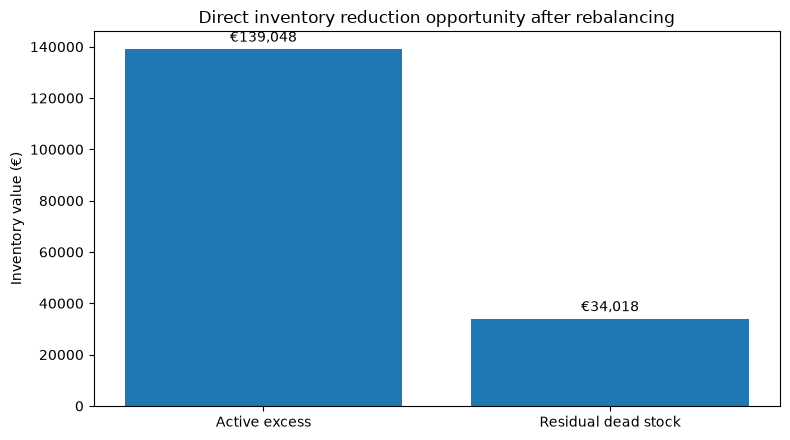

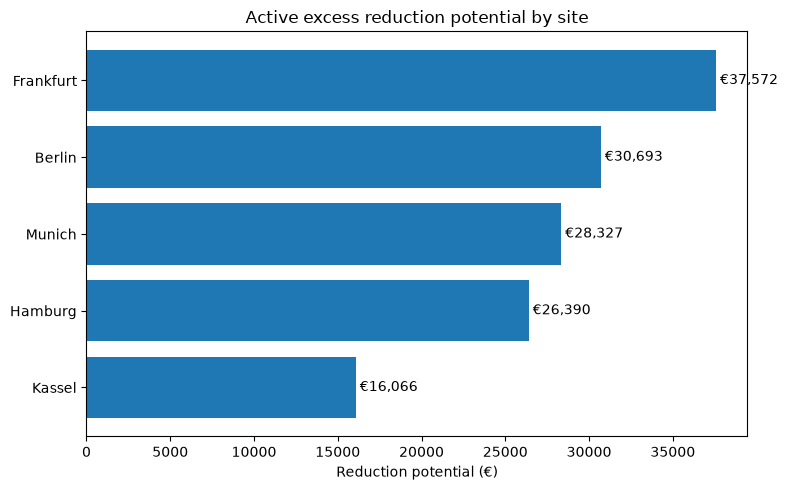

Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C13_direct_inventory_reduction.png
Saved to: c:\Users\angel\Desktop\2026 Summer\PWC Case Study\outputs\C13b_active_excess_by_site.png


In [59]:
# ============================================================
# C14 — Management-ready Task C visualizations
# ============================================================

import matplotlib.pyplot as plt


# ------------------------------------------------------------
# Figure 1 — Direct inventory reduction opportunity
# ------------------------------------------------------------

opportunity_chart = pd.DataFrame({
    "Category": [
        "Active excess",
        "Residual dead stock"
    ],
    "Value_EUR": [
        active_excess_value,
        residual_dead_stock_value
    ]
})

fig, ax = plt.subplots(
    figsize=(8, 4.5)
)

bars = ax.bar(
    opportunity_chart["Category"],
    opportunity_chart["Value_EUR"]
)

ax.bar_label(
    bars,
    labels=[
        f"€{value:,.0f}"
        for value in opportunity_chart["Value_EUR"]
    ],
    padding=3
)

ax.set_title(
    "Direct inventory reduction opportunity after rebalancing"
)

ax.set_ylabel("Inventory value (€)")
ax.set_xlabel("")

fig.tight_layout()

direct_opportunity_fig_path = (
    OUTPUT_DIR / "C13_direct_inventory_reduction.png"
)

fig.savefig(
    direct_opportunity_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Figure 2 — Active excess by site
# ------------------------------------------------------------

site_plot = (
    c_active_excess_by_site
    .sort_values(
        "Active_Excess_Reduction_Potential_EUR",
        ascending=True
    )
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.barh(
    site_plot["Site City"],
    site_plot["Active_Excess_Reduction_Potential_EUR"]
)

ax.bar_label(
    bars,
    labels=[
        f"€{value:,.0f}"
        for value in site_plot[
            "Active_Excess_Reduction_Potential_EUR"
        ]
    ],
    padding=3
)

ax.set_title(
    "Active excess reduction potential by site"
)

ax.set_xlabel("Reduction potential (€)")
ax.set_ylabel("")

fig.tight_layout()

site_excess_fig_path = (
    OUTPUT_DIR / "C13b_active_excess_by_site.png"
)

fig.savefig(
    site_excess_fig_path,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print(f"Saved to: {direct_opportunity_fig_path}")
print(f"Saved to: {site_excess_fig_path}")

In [62]:
# ============================================================
# C15 — Final Task C management summary
# ============================================================

# ------------------------------------------------------------
# 1. Build final numeric metrics
# ------------------------------------------------------------

c_final_metrics = pd.DataFrame([
    {
        "Gross_Modeled_Reduction_Potential_EUR":
            total_reduction_potential,

        "Dead_Stock_Value_EUR":
            dead_stock_value,

        "Rebalanced_Stock_Value_EUR":
            rebalanced_stock_value,

        "Residual_Dead_Stock_Value_EUR":
            residual_dead_stock_value,

        "Active_Excess_Reduction_Potential_EUR":
            active_excess_value,

        "Direct_Inventory_Reduction_Opportunity_EUR":
            direct_inventory_reduction_value,

        "Potential_Annual_Capital_Cost_Saving_EUR":
            direct_annual_capital_cost_effect,

        "Intermittent_Demand_Positions":
            intermittent_position_count,

        "Demand_Down_Inventory_Up_Sites":
            mismatch_site_count,

        "WACC_Assumption":
            WACC,

        "Target_MOS_Assumption":
            TARGET_MOS
    }
])


# ------------------------------------------------------------
# 2. Build final management summary
# ------------------------------------------------------------

c_management_summary = pd.DataFrame([
    {
        "Topic":
            "Demand–inventory mismatch",

        "Evidence":
            (
                f"Network demand changed "
                f"{network_demand_change_pct:+.1f}% while average "
                f"inventory value changed "
                f"{network_inventory_change_pct:+.1f}%; "
                f"{mismatch_site_count} site(s) show demand down "
                f"and inventory up"
            ),

        "Recommendation":
            "Tighten replenishment and review inventory targets, "
            "especially for high-excess Site × Product positions",

        "Financial_Interpretation":
            (
                f"Active-excess reduction potential: "
                f"€{active_excess_value:,.0f}"
            )
    },

    {
        "Topic":
            "Dead-stock allocation",

        "Evidence":
            (
                f"Dead stock totals €{dead_stock_value:,.0f}; "
                f"€{rebalanced_stock_value:,.0f} can potentially "
                f"be reused at other sites under the modeled target"
            ),

        "Recommendation":
            "Rebalance usable stock internally before considering "
            "markdown or scrap",

        "Financial_Interpretation":
            "Rebalancing is reuse, not direct network inventory saving"
    },

    {
        "Topic":
            "Residual dead stock",

        "Evidence":
            (
                f"€{residual_dead_stock_value:,.0f} remains after "
                f"the modeled internal rebalancing"
            ),

        "Recommendation":
            "Use outlet / markdown first and scrap only as last resort",

        "Financial_Interpretation":
            (
                f"Potential annual capital-cost effect ≈ "
                f"€{residual_dead_stock_value * WACC:,.0f}"
            )
    },

    {
        "Topic":
            "Intermittent demand",

        "Evidence":
            (
                f"{intermittent_position_count} active Site × Product "
                f"positions have zero-demand months"
            ),

        "Recommendation":
            "Use inactive periods and demand variability as explicit "
            "replenishment signals",

        "Financial_Interpretation":
            "Financial potential overlaps with active excess and is "
            "therefore not added separately"
    },

    {
        "Topic":
            "Overall quantified opportunity",

        "Evidence":
            (
                f"Direct network inventory reduction opportunity: "
                f"€{direct_inventory_reduction_value:,.0f}"
            ),

        "Recommendation":
            "Combine immediate stock actions with recurring inventory "
            "control to prevent excess from rebuilding",

        "Financial_Interpretation":
            (
                f"Potential annual capital-cost effect at "
                f"{WACC:.1%} WACC: "
                f"€{direct_annual_capital_cost_effect:,.0f}"
            )
    }
])


# ------------------------------------------------------------
# 3. Save final Task C outputs
# ------------------------------------------------------------

management_summary_path = (
    OUTPUT_DIR / "C14_management_summary.csv"
)

final_metrics_path = (
    OUTPUT_DIR / "C14b_final_metrics.csv"
)

c_management_summary.to_csv(
    management_summary_path,
    index=False
)

c_final_metrics.to_csv(
    final_metrics_path,
    index=False
)


# ------------------------------------------------------------
# 4. Display final results
# ------------------------------------------------------------

print("TASK C — FINAL MANAGEMENT SUMMARY")
display(c_management_summary)

print("\nTASK C — FINAL NUMERIC METRICS")
display(c_final_metrics)

print("\nKey interpretation:")
print(
    f"• Gross modeled inventory opportunity: "
    f"€{total_reduction_potential:,.0f}"
)

print(
    f"• Stock proposed for internal rebalancing: "
    f"€{rebalanced_stock_value:,.0f} "
    f"(not a direct network inventory reduction)"
)

print(
    f"• Direct network inventory reduction opportunity: "
    f"€{direct_inventory_reduction_value:,.0f}"
)

print(
    f"• Potential annual capital-cost effect at "
    f"{WACC:.1%} WACC: "
    f"€{direct_annual_capital_cost_effect:,.0f}"
)

print(f"\nSaved to: {management_summary_path}")
print(f"Saved to: {final_metrics_path}")

NameError: name 'intermittent_position_count' is not defined